# Estadística sobre la muestra final

v5: gráficas unificadas y muestra cortada a M_B=-18

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from astropy.io import fits
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from scipy import stats
import seaborn as sns

In [2]:
# Definición del modelo cosmológico (H0=70, Om0=0.3)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Configuración de rutas (Rutas relativas para portabilidad)
BASE_DIR = os.getcwd()
DATA_FOLDER = os.path.join(BASE_DIR, "datos")
PHOTOMETRY_FILE = "datos_finales_v3_lauramedina.csv"
FITS_FILES = [
    "galSpecInfo-dr8.fits",
    "galSpecLine-dr8.fits",
    "galSpecIndx-dr8.fits",
    "galSpecExtra-dr8.fits"
]

print(f"Modelo Cosmológico: {cosmo}")
print(f"Directorio de datos configurado: {DATA_FOLDER}")

Modelo Cosmológico: FlatLambdaCDM(H0=70.0 km / (Mpc s), Om0=0.3, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.0)
Directorio de datos configurado: /Users/lauramedinacrespo/Documents/TFM/CODE/datos


## Configuración gráfica global

Bloque único de estilo, paleta de colores y tamaños de figura para todo el TFM.

In [3]:
# Estilo base 
plt.style.use('seaborn-v0_8-paper')
sns.set_theme(style='whitegrid', font='serif')

# Parámetros globales 
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':          11,
    'axes.titlesize':     12,
    'axes.titleweight':  'bold',
    'axes.labelsize':     12,
    'xtick.labelsize':    12,
    'ytick.labelsize':    12,
    'legend.fontsize':    12,
    'figure.dpi':         150,
    'figure.figsize':    (8, 6),
    'figure.autolayout':  True,
    'axes.grid':          True,
    'grid.alpha':          0.3,
    'grid.linestyle':     '--',
    'savefig.dpi':        150,
    'savefig.bbox':      'tight',
})

# Paleta de colores del TFM 
TFM_COLORS = {
    'muestra_total': 'lightsteelblue', # azul SDSS 
    'submuestra':    '#E8A838', # dorado  
    'fondo':         '#AAAAAA', # gris neutro 
    'corte':         '#D62728', # rojo (lineas axvline)
    'snr_estricto':  '#5B9BD5', # azul S/N > 5
    'snr_dudoso':    'rosybrown', # violeta 3 < S/N <= 5
    'con_oiii':      'darkseagreen', # verde con [OIII]
    'sin_oiii':      'silver', # gris sin [OIII]
}

# Tamaños estándar de figura 
TFM_FIG = {
    'simple':   (8,  6),
    'apaisado': (10, 5),
    'doble':    (14, 6),
    'cuadro':   (14, 10),
    'bpt':      (10, 8),
    'tira':     (16, 7),
}

print("Configuracion grafica del TFM cargada.")
print(f"  Colores: {list(TFM_COLORS.keys())}")
print(f"  Tamanos: {list(TFM_FIG.keys())}")


Configuracion grafica del TFM cargada.
  Colores: ['muestra_total', 'submuestra', 'fondo', 'corte', 'snr_estricto', 'snr_dudoso', 'con_oiii', 'sin_oiii']
  Tamanos: ['simple', 'apaisado', 'doble', 'cuadro', 'bpt', 'tira']


In [14]:
def plot_histogram_stats(data, title, xlabel,
                         color=None, bins='auto',
                         xlim=None, save_path=None, log=True):
    """
    Histograma con media, mediana y cuartiles Q1/Q3.
    Parametros
    ----------
    data      : pd.Series
    title     : str
    xlabel    : str
    color     : str  — usa TFM_COLORS['...'] (default: muestra_total)
    bins      : int o 'auto'
    xlim      : tupla (min, max) opcional
    save_path : str opcional -> guarda la figura en disco
    """
    if log is True:
      log_elect=True
    else:
      log_elect=False
      
    if color is None:
        color = TFM_COLORS['muestra_total']

    fig, ax = plt.subplots(figsize=TFM_FIG['simple'])

    mu  = data.mean()
    med = data.median()
    q1  = data.quantile(0.25)
    q3  = data.quantile(0.75)

    ax.hist(data, bins=bins, color=color,
            histtype='bar',
            alpha=0.7,
            edgecolor='white',
            linewidth=0.5,
            log=log_elect,
            label='Distribution')

    ax.axvline(mu,  color=TFM_COLORS['corte'], lw=2, label=f'Mean = {mu:.2f}')
    ax.axvline(med, color='forestgreen', lw=2, ls='--', label=f'Median = {med:.2f}')
    ax.axvline(q1,  color='navy', lw=1.5, ls=':', label=f'Q1 = {q1:.2f}')
    ax.axvline(q3,  color='navy', lw=1.5, ls=':', label=f'Q3 = {q3:.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Number of objects')
    if xlim:
        ax.set_xlim(xlim)
    ax.legend()

    if save_path:
        fig.savefig(save_path)
        print(f"Figura guardada en: {save_path}")
    plt.show()


In [27]:
def plot_compare_dwarfs(df_con, df_sin, column, title, xlabel, xlims=None, ylims=None, show_stats=False, save_path=None, manual_bins=None):
    """
    Compara dos poblaciones (Con vs Sin OIII).
    La leyenda se organiza en 2 columnas perfectas: [CON OIII] (Azul) y [SIN OIII] (Gris).
    """
    # Limpieza de datos
    data_con = df_con[column].dropna()
    data_sin = df_sin[column].dropna()
    
    if len(data_con) < 2 or len(data_sin) < 2:
        print(f"Datos insuficientes en la columna '{column}' para graficar.")
        return

    # Cálculo de Estadísticas
    med_con, mu_con = data_con.median(), data_con.mean()
    q1_con, q3_con = data_con.quantile(0.25), data_con.quantile(0.75)
    
    med_sin, mu_sin = data_sin.median(), data_sin.mean()
    q1_sin, q3_sin = data_sin.quantile(0.25), data_sin.quantile(0.75)
    
    # Preparación de la Figura y Bins
    plt.figure(figsize=(10, 6))
    combined_data = np.concatenate([data_con, data_sin])
    if manual_bins:
        bins = manual_bins
    else:
        bins = np.histogram_bin_edges(combined_data, bins='auto')

    # Dibujamos todo
    
    # FILA 1: Las distribuciones
    plt.hist(data_con, bins=bins, density=True, color=TFM_COLORS['con_oiii'], alpha=0.6, 
             label=f'With [OIII] (N={len(data_con)})')
    plt.hist(data_sin, bins=bins, density=True, color=TFM_COLORS['sin_oiii'], alpha=0.5, 
             label=f'Without [OIII] (N={len(data_sin)})')
   
    # FILA 2: Las Medianas
    plt.axvline(med_con, color='mediumseagreen', linestyle='--', lw=2, label=f'Median: {med_con:.2f}')
    plt.axvline(med_sin, color='dimgray', linestyle='--', lw=2, label=f'Median: {med_sin:.2f}')

    # ESTADÍSTICA COMPLETA (opcional)
    if show_stats:
        # FILA 3: Las Medias
        plt.axvline(mu_con, color='seagreen', linestyle='-.', alpha=0.7, lw=1.5, label=f'Mean: {mu_con:.2f}')
        plt.axvline(mu_sin, color='gray', linestyle='-.', alpha=0.7, lw=1.5, label=f'Mean: {mu_sin:.2f}')
        
        # FILA 4: Cuartil 1 (Q1 - 25%)
        plt.axvline(q1_con, color='seagreen', linestyle=':', alpha=0.8, lw=1.5, label=f'Q1: {q1_con:.2f}')
        plt.axvline(q1_sin, color='gray', linestyle=':', alpha=0.8, lw=1.5, label=f'Q1: {q1_sin:.2f}')
        
        # FILA 5: Cuartil 3 (Q3 - 75%)
        plt.axvline(q3_con, color='seagreen', linestyle=':', alpha=0.8, lw=1.5, label=f'Q3: {q3_con:.2f}')
        plt.axvline(q3_sin, color='gray', linestyle=':', alpha=0.8, lw=1.5, label=f'Q3: {q3_sin:.2f}')

    # 5. Decoración final
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Normalized Density", fontsize=12)
    
    if xlims:
        plt.xlim(xlims)

    if ylims:
        plt.ylim(ylims)
        
    # Para ordenar la leyenda en dos columnas 
    ax = plt.gca() # Obtenemos el gráfico actual
    handles, labels = ax.get_legend_handles_labels()
    
    # Extraemos todos los pares (índices 0, 2, 4...) que son el Grupo CON
    # y luego le sumamos todos los impares (índices 1, 3, 5...) que son el Grupo SIN
    handles_reordered = handles[::2] + handles[1::2]
    labels_reordered = labels[::2] + labels[1::2]
    
    # Ahora dibujamos la leyenda pasándole las listas ordenadas
    plt.legend(handles_reordered, labels_reordered, loc='best', ncol=2, 
               frameon=True, shadow=True, fontsize=8.5, columnspacing=1.5, handletextpad=0.5)
        
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()

    if save_path:
        # bbox_inches='tight' asegura que no se corten las etiquetas al guardar
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figura guardada en: {save_path}")
      
    plt.show()

In [41]:
def inspeccionar_galaxias_spec(df, n=10):
    print(f"Inspección visual (SDSS SKYSERVER) - {len(df)} objetos")
    
    # Definir columnas clave
    cols_oiii = ['OIII_4363_FLUX']
    
    # Columnas obligatorias
    cols_base = ['SPECOBJID', 'RA', 'DEC', 'Z', 'modelMag_g', 'H_BETA_FLUX']
    
    # Columnas físicas extras
    cols_fisica = ['LOG_M_STAR', 'ABS_MAG_r_sdss', 'ABS_MAG_B', 'ABS_MAG_V'] 
    
    # Filtrar solo las columnas que realmente existen en el DataFrame
    cols_finales = [c for c in cols_base + cols_fisica + cols_oiii if c in df.columns]
    
    # La muestra
    # Usamos .copy() para no modificar el original al formatear
    sample = df[cols_finales].head(n).copy()
    
    # Formateo del SPECOBJID
    # Forzamos que se vea como un número entero largo, no como 1.23e+18
    if 'SPECOBJID' in sample.columns:
        # Primero aseguramos que sea numérico, luego string sin decimales
        sample['SPECOBJID'] = sample['SPECOBJID'].apply(lambda x: f"{int(float(x))}")

    print("\nDatos de la muestra")
    print(sample.to_string(index=False))
    
    print("\nENLACES")
    print("Haz click para ver el espectro y la imagen real:\n")
    
    # Generar enlaces
    base_url_id = "http://skyserver.sdss.org/dr18/en/tools/explore/Summary.aspx?sid="
    base_url_coords = "http://skyserver.sdss.org/dr18/en/tools/chart/navi.aspx"
    
    for i, row in sample.iterrows():
        spec_id = row['SPECOBJID']
        ra = row['RA']
        dec = row['DEC']
        z = row['Z']
        
        # Intentamos obtener algún valor de OIII para mostrarlo en el texto del link
        val_oiii = ""
        if len(cols_oiii) > 0:
            # Tomamos la primera columna de OIII que encontramos
            col_val = cols_oiii[0]
            val_oiii = f" | {col_val}: {row[col_val]:.2f}"

        # Enlace principal (por ID Espectroscópico - sid)
        link_id = f"{base_url_id}{spec_id}"
        
        # Enlace de respaldo (por Coordenadas - visualizador de mapa)
        link_coords = f"{base_url_coords}?ra={ra}&dec={dec}&scale=0.1"
        
        print(f"[{i}] Z={z:.4f}{val_oiii}")
        print(f"> Explorer (Datos): {link_id}")
        print(f"> Mapa (Imagen):    {link_coords}")
        print("-" * 50)

In [6]:
checkpoint_filename = "SDSS_Master_FINAL_CHECKPOINT_v3.pkl"
checkpoint_path = os.path.join(DATA_FOLDER, checkpoint_filename)

if os.path.exists(checkpoint_path):
    print("Cargando desde Pickle...")
    df = pd.read_pickle(checkpoint_path)
    print(f"-> Cargadas {len(df)} galaxias.")
else:
    print("No existe el checkpoint.")

Cargando desde Pickle...
-> Cargadas 312474 galaxias.


### Calculos previos a la estadística

La anchura equivalente hay que multiplicarla por -1 para que la emisión sea positiva.

In [7]:
# Invertir signo de REQW para que emisión sea positiva
df['OIII_4363_REQW'] = df['OIII_4363_REQW'] * -1

In [8]:
if 'L_OIII_4363_Log' not in df.columns:
    print("Calculando luminosidad [OIII]4363...")
    df['L_OIII_4363_Log'] = np.nan
    
    flux_limpio = df['OIII_4363_FLUX'].replace(-9999, np.nan).replace(-9999.0, np.nan)
    mask_valid_oiii = flux_limpio > 0
    print(f"Galaxias con flujo válido: {mask_valid_oiii.sum()}")
    
    z_values = df.loc[mask_valid_oiii, 'Z'].values.astype(float)
    
    # Conversión manual Mpc → cm (evita el problema con .to())
    dist_mpc = cosmo.luminosity_distance(z_values).value       # en Mpc
    dist_cm  = dist_mpc * 3.085677581e24                       # 1 Mpc en cm
    
    flux_cgs  = flux_limpio.loc[mask_valid_oiii].values * 1e-17
    lum_erg_s = 4 * np.pi * dist_cm**2 * flux_cgs
    
    df.loc[mask_valid_oiii, 'L_OIII_4363_Log'] = np.log10(lum_erg_s)
    print(f"Luminosidad calculada.")

Calculando luminosidad [OIII]4363...
Galaxias con flujo válido: 176414
Luminosidad calculada.


## 1. Definición de la muestra final

Dividimos el catálogo en subgrupos:

Enanas (Dwarfs): Galaxias intrínsecamente débiles ($M_B > -X$). -> EnanasX

Enanas18
Enanas16
Enanas14 

Emisoras [OIII]: Galaxias con detección fuerte de la línea auroral 4363 (clave para metalicidad).

Ambas: La intersección. Enanas que además tienen la línea.


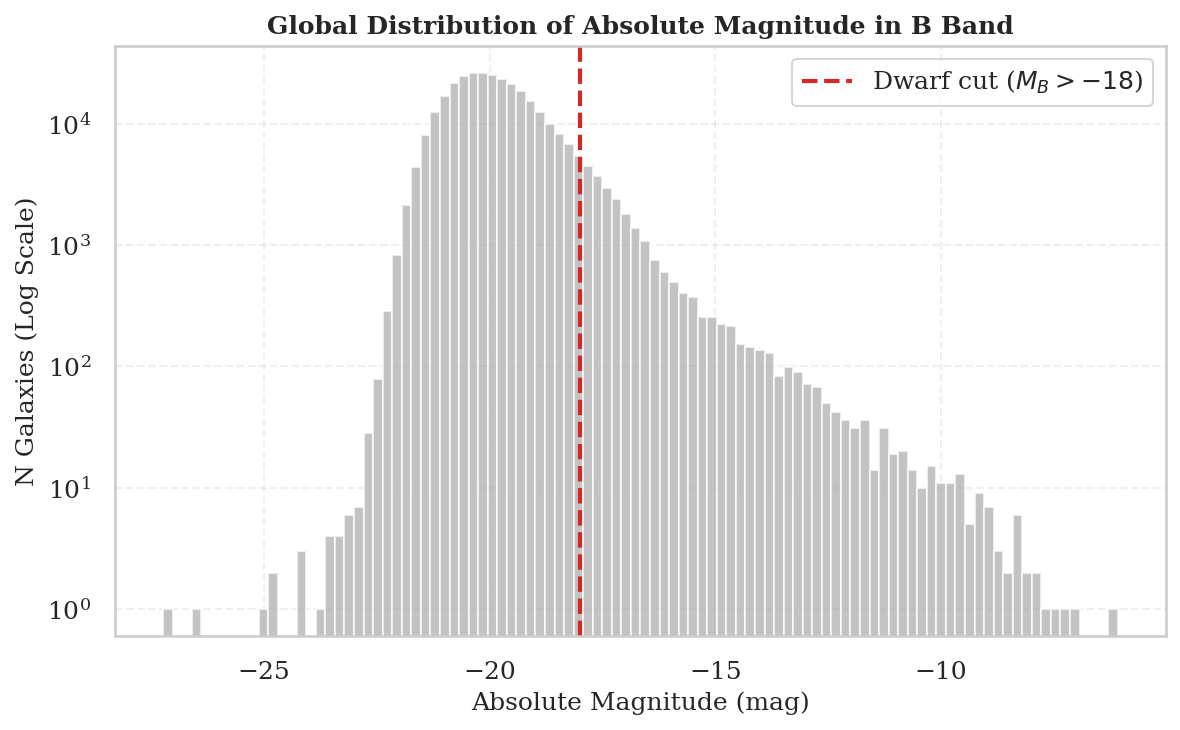

In [9]:
# Histograma de magnitud absoluta B
plt.figure(figsize=(8, 5))
plt.hist(df['ABS_MAG_B'], bins=100, color=TFM_COLORS['fondo'], alpha=0.7, log=True)
plt.axvline(-18, color=TFM_COLORS['corte'], linestyle='--', lw=2, label='Dwarf cut ($M_B>-18$)')
plt.title("Global Distribution of Absolute Magnitude in B Band")
plt.xlabel("Absolute Magnitude (mag)")
plt.ylabel("N Galaxies (Log Scale)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
# LIMPIEZA GLOBAL DEL CATÁLOGO (PRE-FILTRADO)
# Nos aseguramos de que las columnas clave sean numéricas
cols_to_check = ['H_BETA_FLUX', 'OIII_5007_FLUX']
for col in cols_to_check:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Condiciones de limpieza física:
mask_hb_val = (df['H_BETA_FLUX'] > 0) & (df['H_BETA_FLUX'] < 100000) # H-beta físico y emisión
mask_oiii5007_val = (df['OIII_5007_FLUX'] > 0) & (df['OIII_5007_FLUX'] < 100000) # OIII 5007 físico
# [OIII]5007 es línea prohibida: solo existe en emisión.
# Flujo <= 0 indica no-detección o ruido por lo que descartamos

# Aplicamos todas las máscaras para crear nuestro DataFrame limpio
mask_clean = mask_hb_val & mask_oiii5007_val
df_clean = df[mask_clean].copy()

print(f"Galaxias originales: {len(df)}")
print(f"Galaxias limpias:    {len(df_clean)}")
print(f"Artefactos borrados: {len(df) - len(df_clean)}\n")

Galaxias originales: 312474
Galaxias limpias:    311147
Artefactos borrados: 1327



In [11]:
# Reemplazar -9999 por NaN en todo el DataFrame
SENTINEL = -9999
TOL = 0.5  # cualquier valor en (-9999.5, -9998.5) se considera centinela

# Solo actuamos sobre columnas numéricas para no tocar strings
cols_numericas = df_clean.select_dtypes(include=[np.number]).columns

n_reemplazos = 0
for col in cols_numericas:
    mask = np.abs(df_clean[col] - SENTINEL) < TOL
    n_reemplazos += mask.sum()
    df_clean.loc[mask, col] = np.nan

print(f"Reemplazos realizados: {n_reemplazos:,} valores -9999 → NaN")
print(f"Columnas revisadas: {len(cols_numericas)}")

Reemplazos realizados: 1,267,031 valores -9999 → NaN
Columnas revisadas: 674


In [12]:
# SELECCIÓN DE SUBGRUPOS (ENANAS Y OIII)
# parámetros definición
dwarf_limits = [-18.0, -16.0, -14.0] # Umbral de magnitud
SN_OIII_MIN = 3.0 # S/N mínimo para confiar en la línea 4363

# 1. DETECCIÓN DE LÍNEA [OIII]4363 (SOBRE EL DF LIMPIO)
col_flux = 'OIII_4363_FLUX' 
col_err = 'OIII_4363_FLUX_ERR'

if col_flux in df_clean.columns:
    # Calculamos S/N (Flux / Error), protegiendo división por cero
    sn_4363 = np.where(df_clean[col_err] > 0, df_clean[col_flux] / df_clean[col_err], 0)
    
    # Creamos máscara 
    mask_oiii = (sn_4363 > SN_OIII_MIN) & (df_clean[col_flux] > 0)
    print(f"Detecciones de [OIII]4363 (S/N > {SN_OIII_MIN}): {mask_oiii.sum()} galaxias")
else:
    print(f" ERROR: No se encuentra la columna {col_flux}")
    mask_oiii = np.zeros(len(df_clean), dtype=bool)

# 2. DETECCIÓN DE ENANAS (por magnitud absoluta)
# Creamos el diccionario
results_dwarf = {}
for limit in dwarf_limits:
    # Usamos df_clean en todo este bloque
    mask_dwarf = df_clean['ABS_MAG_B'] > limit
    
    # Enanas CON OIII (Intersección)
    mask_con_oiii = mask_dwarf & mask_oiii
    
    # Enanas SIN OIII (Diferencia)
    mask_sin_oiii = mask_dwarf & (~mask_oiii)
    
    # dataframes
    df_dwarfs = df_clean[mask_dwarf].copy() # Total enanas
    df_con = df_clean[mask_con_oiii].copy()# Enanas con OIII
    df_sin = df_clean[mask_sin_oiii].copy() # Enanas sin OIII

    # Guardamos en diccionario
    results_dwarf[limit] = {
        'total': df_dwarfs,
        'con_oiii': df_con,
        'sin_oiii': df_sin
    }

    # Imprimimos números
    print(f"\nLímite Mag: {limit}")
    print(f"Muestra total (Limpias): {len(df_clean)}")
    print(f"1. Total Enanas:       {len(df_dwarfs)}")
    print(f"2. Enanas CON OIII:    {len(df_con)}")
    print(f"3. Enanas SIN OIII:    {len(df_sin)}")
    
    # Check: la suma de con+sin debe ser igual al total
    suma = len(df_con) + len(df_sin)
    check = "correcto" if suma == len(df_dwarfs) else "error"
    print(f"Check: {len(df_con)} + {len(df_sin)} = {suma} ({check})")

Detecciones de [OIII]4363 (S/N > 3.0): 5862 galaxias

Límite Mag: -18.0
Muestra total (Limpias): 311147
1. Total Enanas:       24384
2. Enanas CON OIII:    1473
3. Enanas SIN OIII:    22911
Check: 1473 + 22911 = 24384 (correcto)

Límite Mag: -16.0
Muestra total (Limpias): 311147
1. Total Enanas:       3505
2. Enanas CON OIII:    437
3. Enanas SIN OIII:    3068
Check: 437 + 3068 = 3505 (correcto)

Límite Mag: -14.0
Muestra total (Limpias): 311147
1. Total Enanas:       982
2. Enanas CON OIII:    104
3. Enanas SIN OIII:    878
Check: 104 + 878 = 982 (correcto)


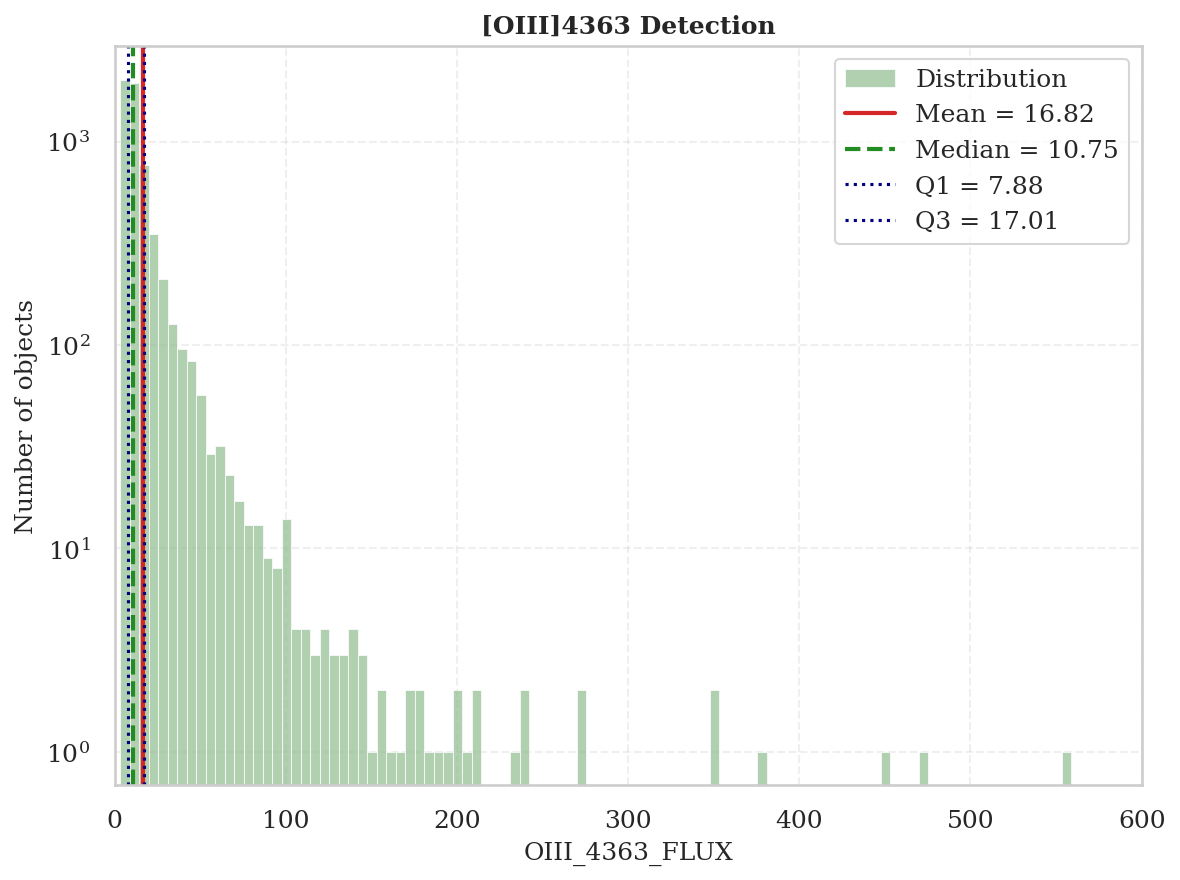

In [15]:
data = df_clean[mask_oiii]['OIII_4363_FLUX']
data = data[(data > 0) & (data < 100000)]   # rango físico razonable

plot_histogram_stats(data, title='[OIII]4363 Detection', xlabel='OIII_4363_FLUX',
                     color=TFM_COLORS['con_oiii'], bins=100,
                     xlim=(0, 600), save_path=None, log=True)

## 2. Visualización de Resultados Finales

Usamos la función plot_histogram_stats (de la Celda 4) para verlos datos definitivos.

Aquí verificaremos si la Masa Estelar tiene forma de campana (normal) o sigue plana.

Usamos la muestra de enanas con [OIII]4363 y MB límite -18

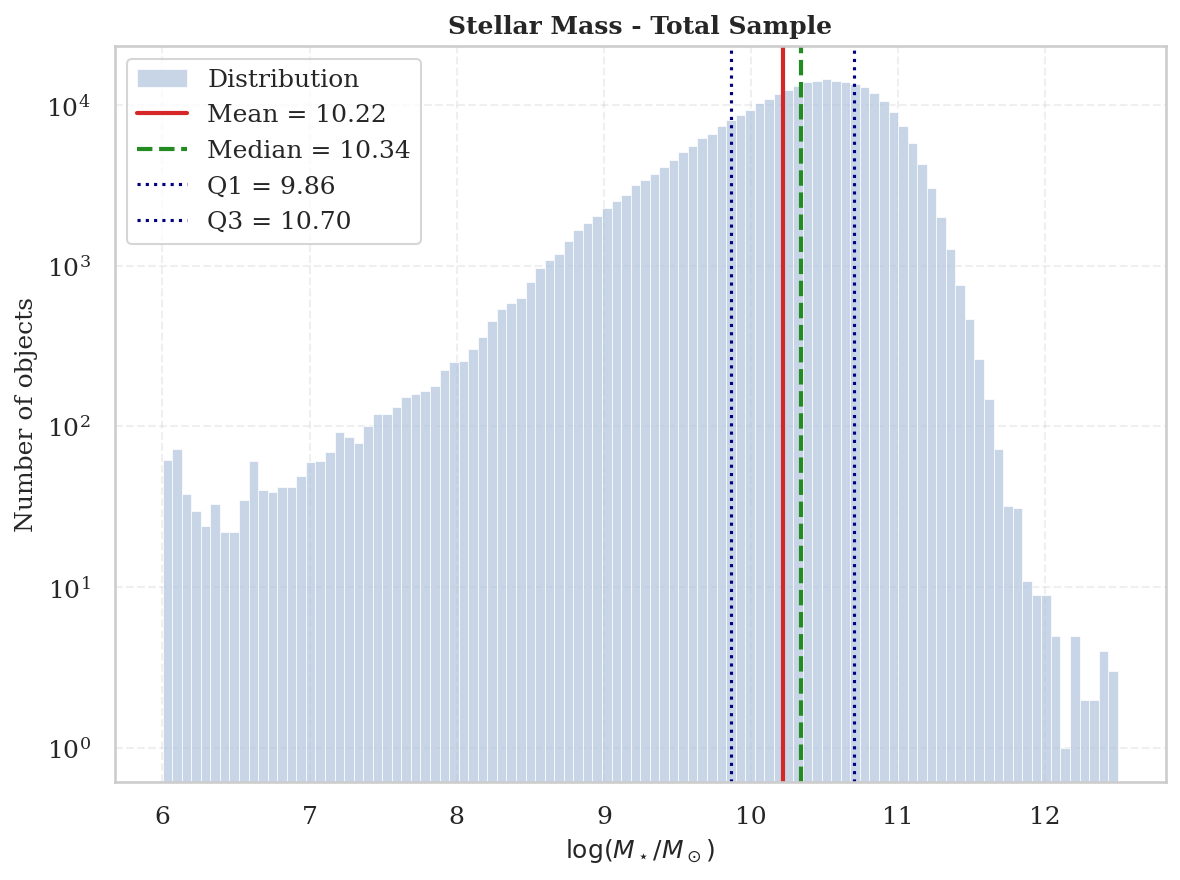

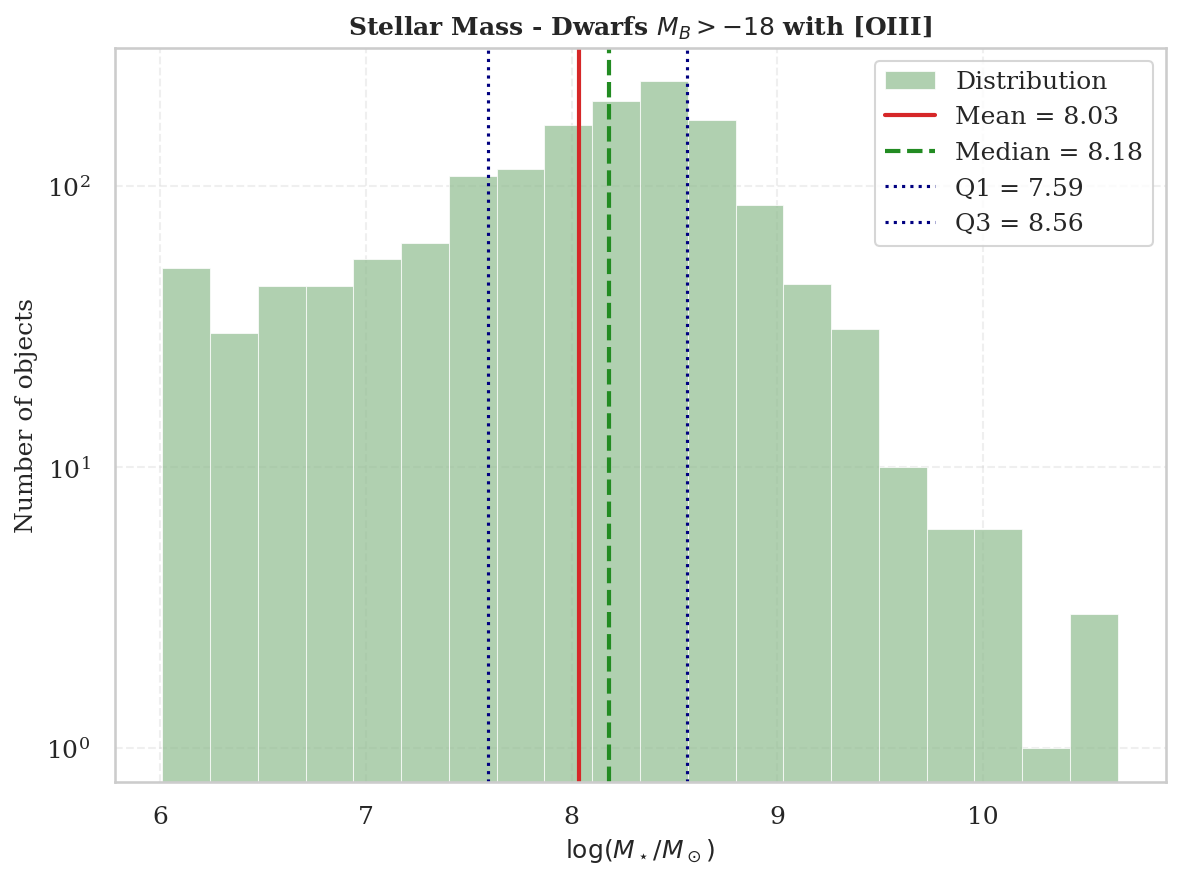

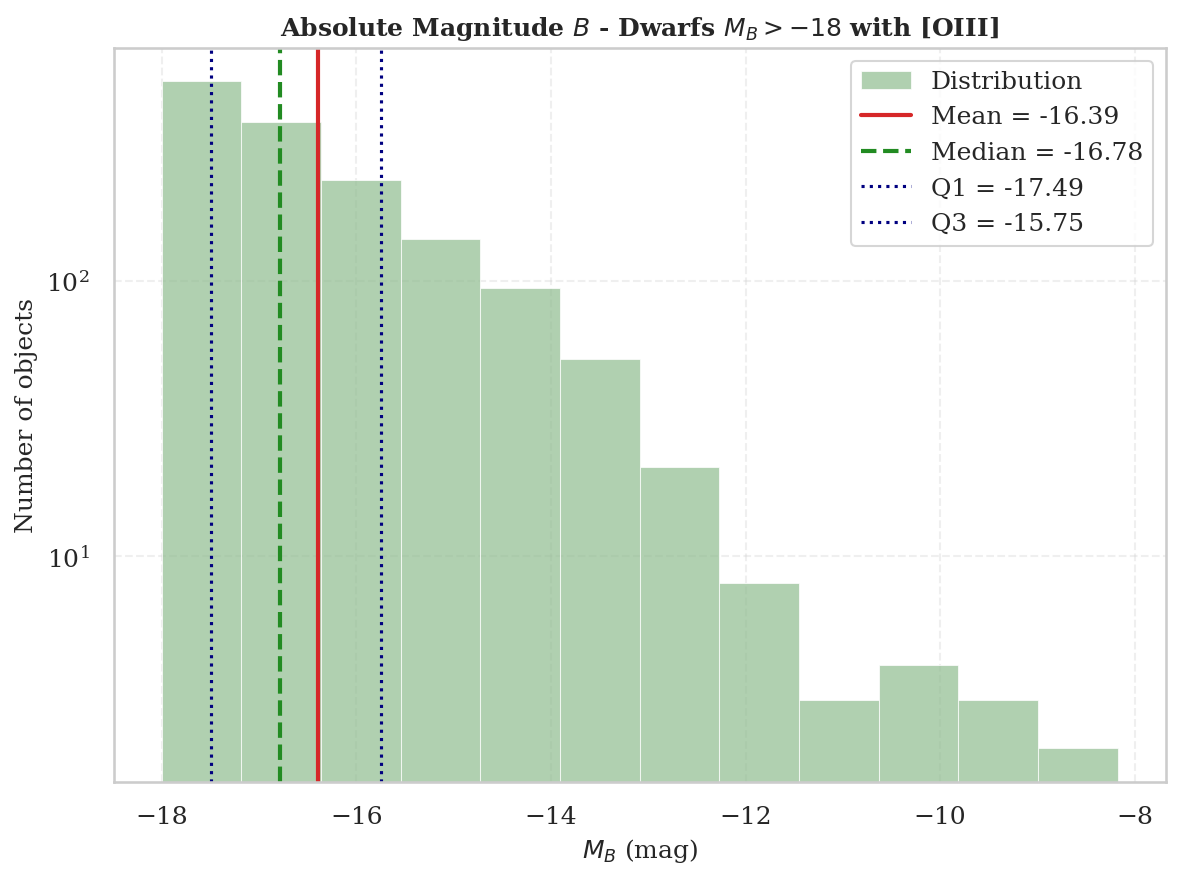

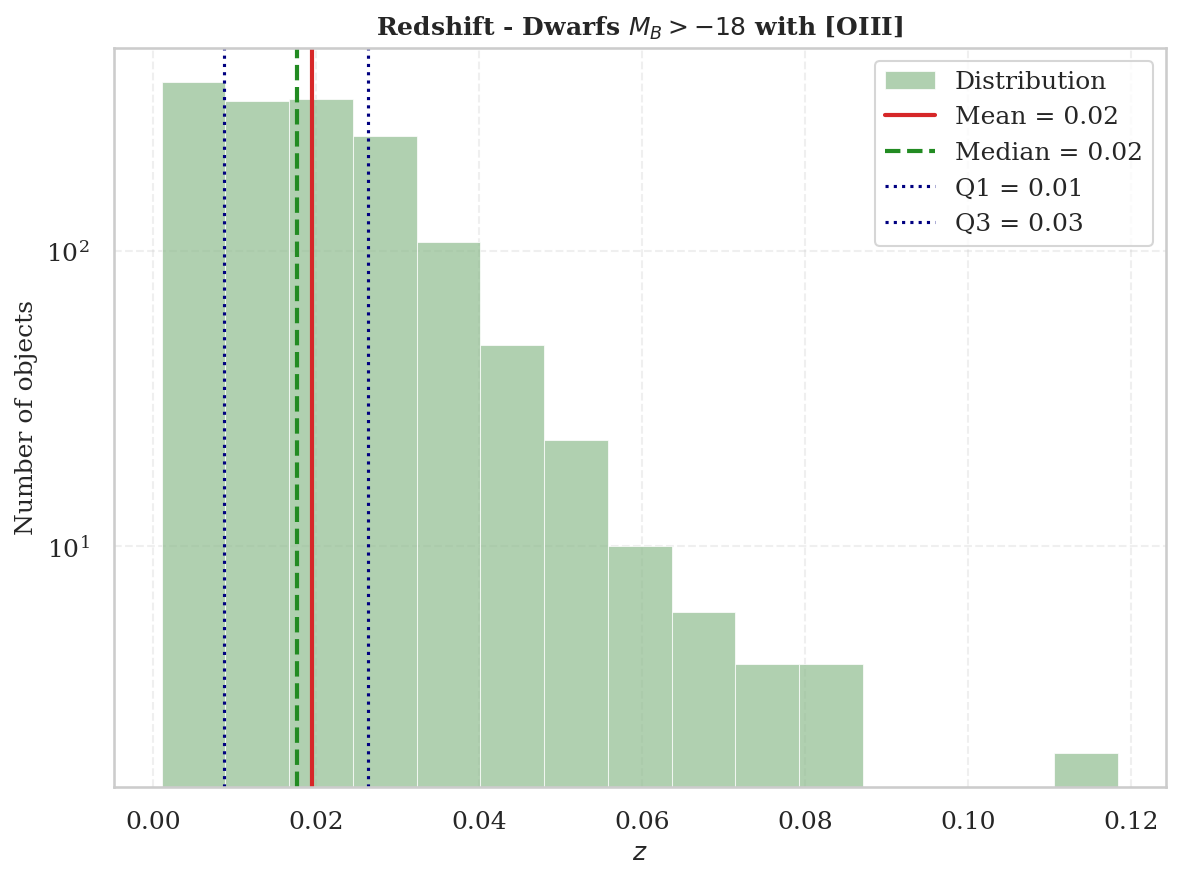

Resumen estadístico de la Submuestra (Enanas16 + OIII):
Masa Estelar Promedio: 8.03 (Log Solar)
Magnitud B Promedio: -16.39
Redshift Promedio: 0.020


In [17]:
df_dwarf18_oiii = results_dwarf[-18]['con_oiii']

# MASA 
plot_histogram_stats(df['LGM_TOT_P50'],
                     "Stellar Mass - Total Sample",
                     r"$\log(M_\star/M_\odot)$", color=TFM_COLORS['muestra_total'],
                     bins=100) 

plot_histogram_stats(df_dwarf18_oiii['LGM_TOT_P50'],
                     "Stellar Mass - Dwarfs $M_B > -18$ with [OIII]",
                     r"$\log(M_\star/M_\odot)$", color=TFM_COLORS['con_oiii'],
                     bins=20)  

# MAGNITUD B 
plot_histogram_stats(df_dwarf18_oiii['ABS_MAG_B'],
                     r"Absolute Magnitude $B$ - Dwarfs $M_B > -18$ with [OIII]",
                     r"$M_B$ (mag)", color=TFM_COLORS['con_oiii'],
                     bins=12) 

# REDSHIFT 
plot_histogram_stats(df_dwarf18_oiii['Z'],
                     r"Redshift - Dwarfs $M_B > -18$ with [OIII]",
                     r"$z$", color=TFM_COLORS['con_oiii'],
                     bins=15)

# 2. Resumen Estadístico Numérico
print("Resumen estadístico de la Submuestra (Enanas16 + OIII):")
print(f"Masa Estelar Promedio: {df_dwarf18_oiii['LGM_TOT_P50'].mean():.2f} (Log Solar)")
print(f"Magnitud B Promedio: {df_dwarf18_oiii['ABS_MAG_B'].mean():.2f}")
print(f"Redshift Promedio: {df_dwarf18_oiii['Z'].mean():.3f}")


### Comparamos las masas

Figura guardada en: comp_masa


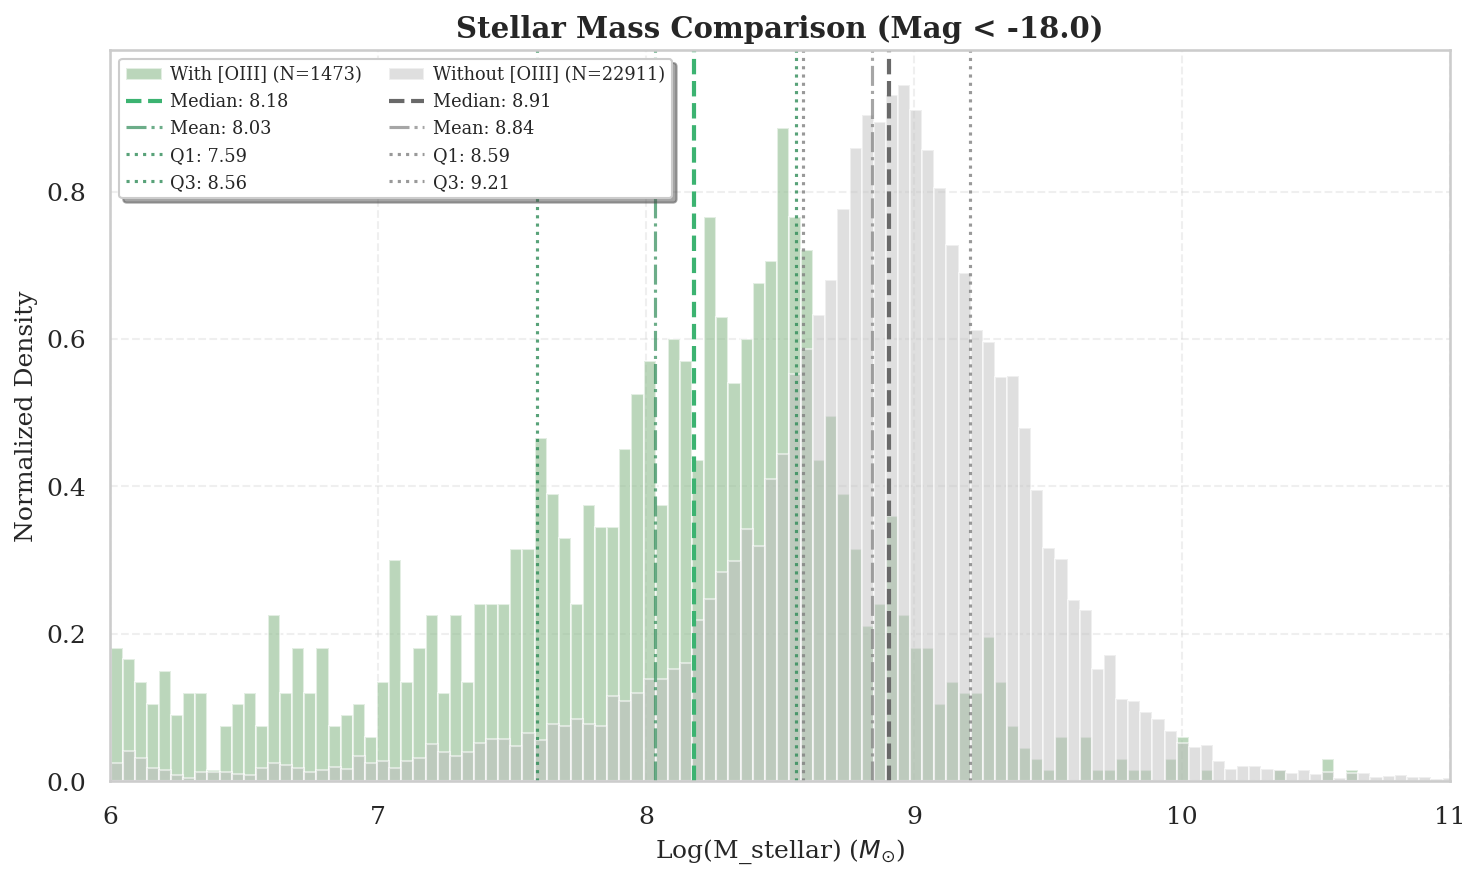

In [19]:
variable_a_analizar = 'LGM_TOT_P50'  
nombre_variable = r'Log(M_stellar) ($M_{\odot}$)'

# Iteramos sobre el diccionario de resultados
# Solo procesamos el corte M_B > -18
if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    df_c = data['con_oiii']
    df_s = data['sin_oiii']
    
    titulo = f"Stellar Mass Comparison (Mag < {limit_mag})"
    
    plot_compare_dwarfs(df_c, df_s, 
                        column=variable_a_analizar, 
                        title=titulo, 
                        xlabel=nombre_variable,
                        show_stats=True,
                        xlims=(6,11),
                        save_path='comp_masa'
                        )

### Comparamos la magnitud aparente

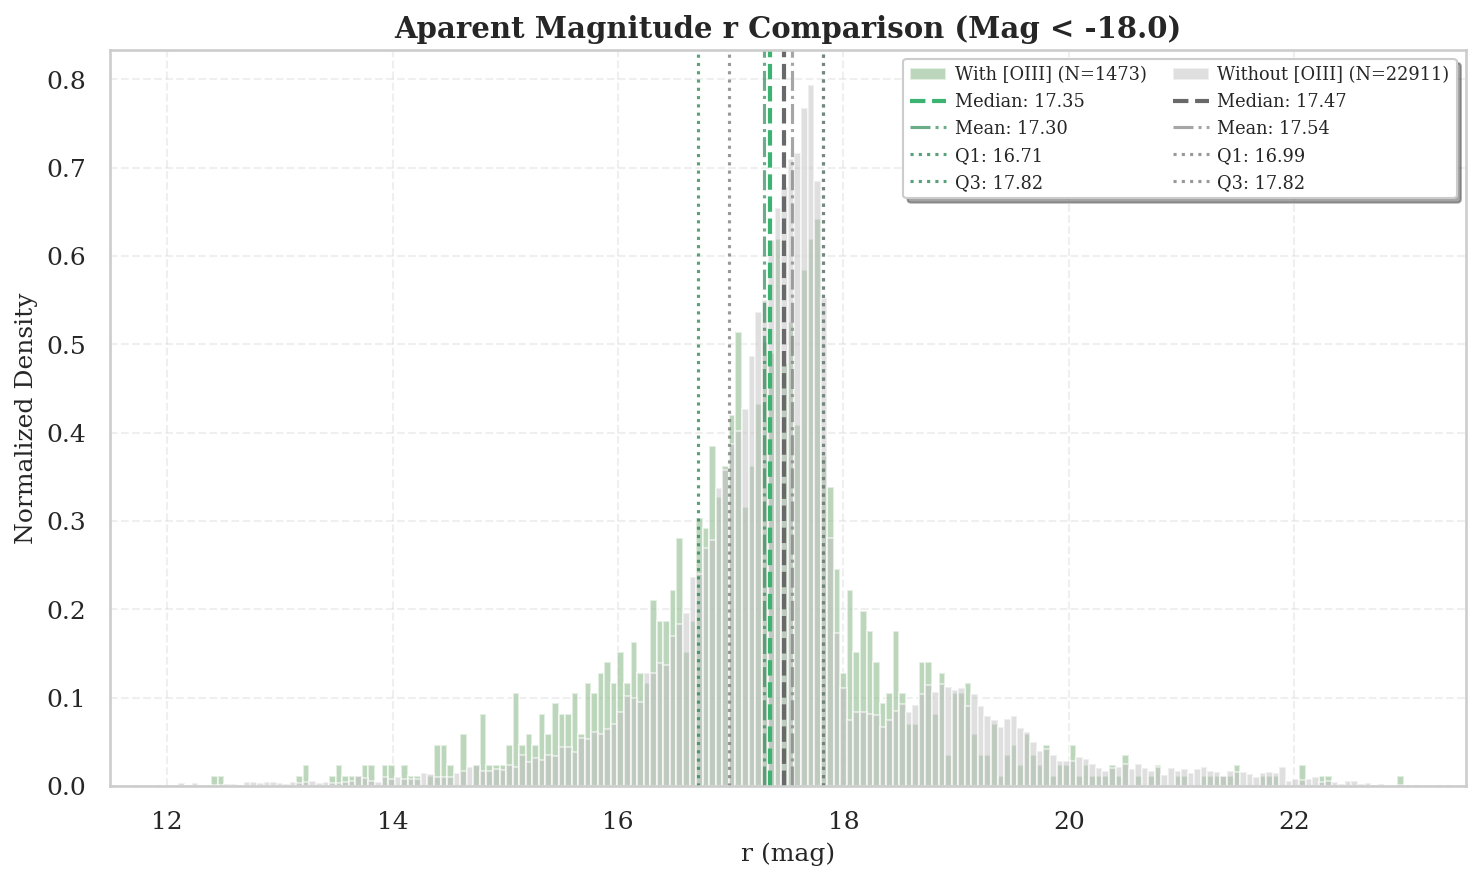

In [20]:
variable_a_analizar = 'modelMag_r'  
nombre_variable = 'r (mag)'

# Iteramos sobre tu diccionario de resultados
# Solo procesamos el corte M_B > -18
if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    df_c = data['con_oiii']
    df_s = data['sin_oiii']
    
    titulo = f"Aparent Magnitude r Comparison (Mag < {limit_mag})"
    
    plot_compare_dwarfs(df_c, df_s, 
                        column=variable_a_analizar, 
                        title=titulo, 
                        xlabel=nombre_variable,
                        show_stats=True)

### Comparamos la Tasa de formación estelar específica

Figura guardada en: comp_ssfr


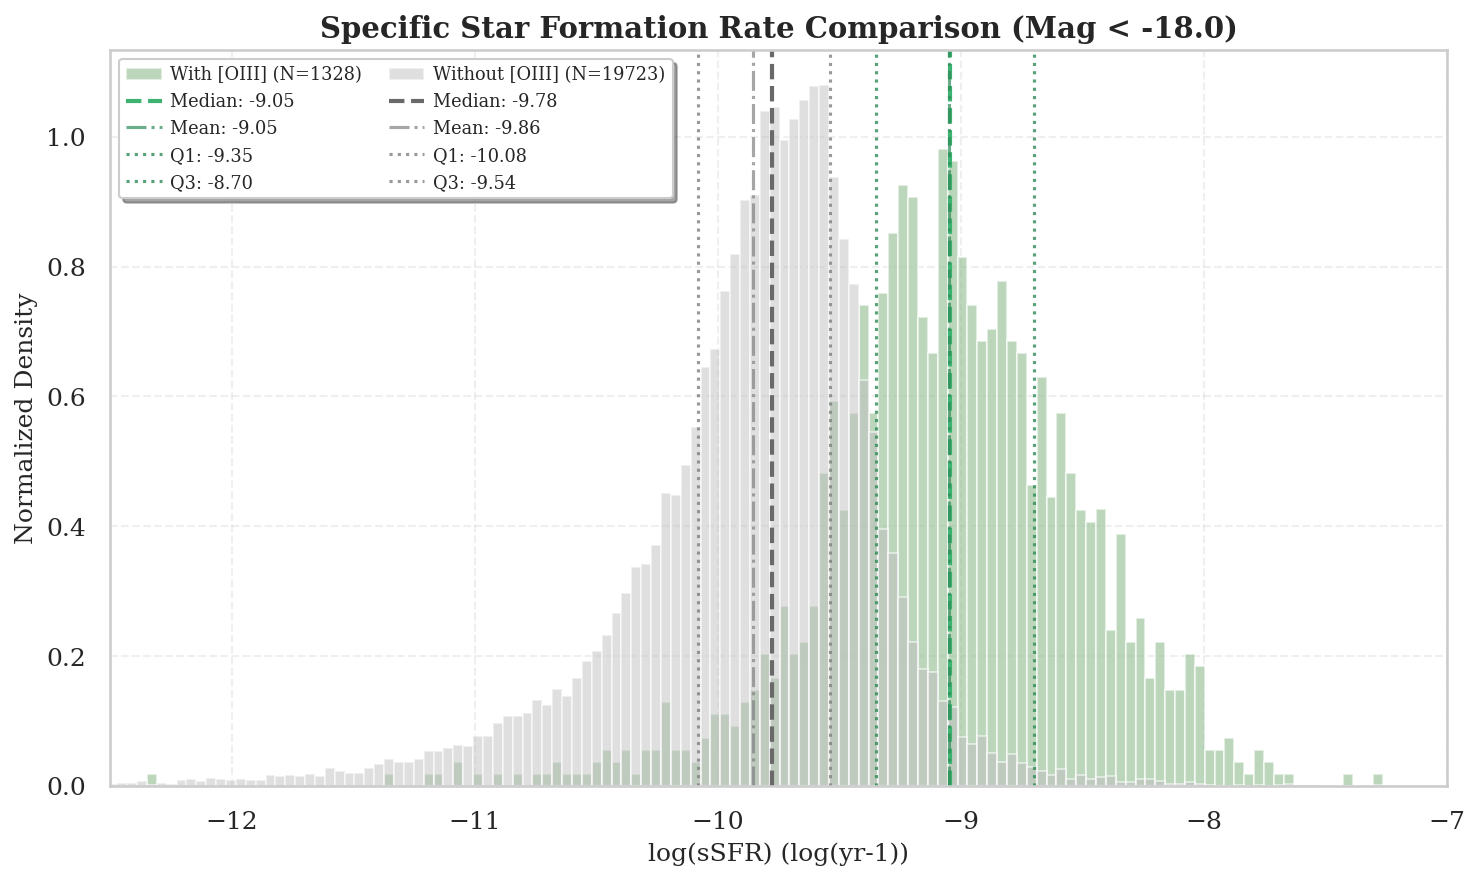

In [21]:
variable_a_analizar = 'SPECSFR_TOT_P50'  
nombre_variable = 'log(sSFR) (log(yr-1))'

# Iteramos sobre tu diccionario de resultados
# Solo procesamos el corte M_B > -18
if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    df_c = data['con_oiii']
    df_s = data['sin_oiii']
    
    titulo = f"Specific Star Formation Rate Comparison (Mag < {limit_mag})"
    
    plot_compare_dwarfs(df_c, df_s, 
                        column=variable_a_analizar, 
                        title=titulo, 
                        xlabel=nombre_variable,
                        show_stats=True,
                        xlims=(-12.5, -7),
                        save_path='comp_ssfr')

### Comparamos el flujo H beta

Figura guardada en: comp_flujo_hbeta


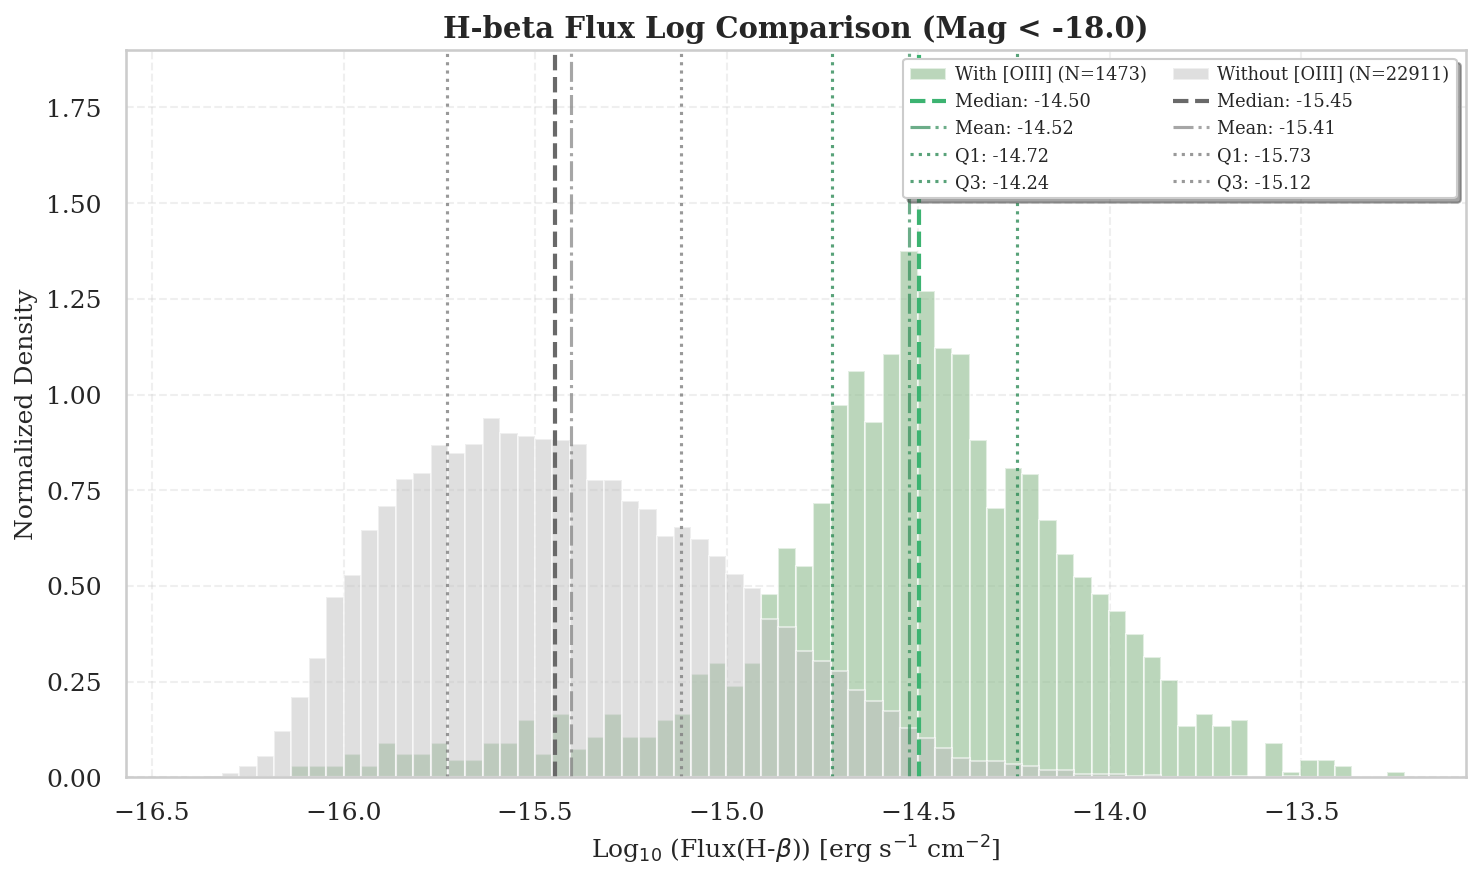

In [30]:
# Corrección del nombre para reflejar la notación científica física
columna_original = 'H_BETA_FLUX'
columna_calculada = 'log_h_beta'
nombre_eje = r'Log$_{10}$ (Flux(H-$\beta$)) [erg s$^{-1}$ cm$^{-2}$]'

# Solo procesamos el corte M_B > -18
if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    # Trabajamos con copias para no alterar los datos originales
    df_c = data['con_oiii'].copy()
    df_s = data['sin_oiii'].copy()
    
    # Convertimos a números
    df_c[columna_original] = pd.to_numeric(df_c[columna_original], errors='coerce')
    df_s[columna_original] = pd.to_numeric(df_s[columna_original], errors='coerce')
    
    # FILTRADO PREVIO: Solo flujos positivos
    # El logaritmo de 0 es -infinito y el de negativos es NaN. 
    df_c = df_c[df_c[columna_original] > 0].copy()
    df_s = df_s[df_s[columna_original] > 0].copy()
    
    # CÁLCULO FÍSICO DEL LOGARITMO (Base 10)
    # Añadimos el factor 1e-17 del SDSS antes de aplicar el logaritmo
    df_c[columna_calculada] = np.log10(df_c[columna_original] * 1e-17)
    df_s[columna_calculada] = np.log10(df_s[columna_original] * 1e-17)
    
    titulo = f"H-beta Flux Log Comparison (Mag < {limit_mag})"
    
    plot_compare_dwarfs(df_c, df_s, 
                        column=columna_calculada,
                        title=titulo, 
                        xlabel=nombre_eje,
                        show_stats=True,
                        ylims=(0,1.9),
                        save_path='comp_flujo_hbeta')

Figura guardada en: comp_lum_hbeta


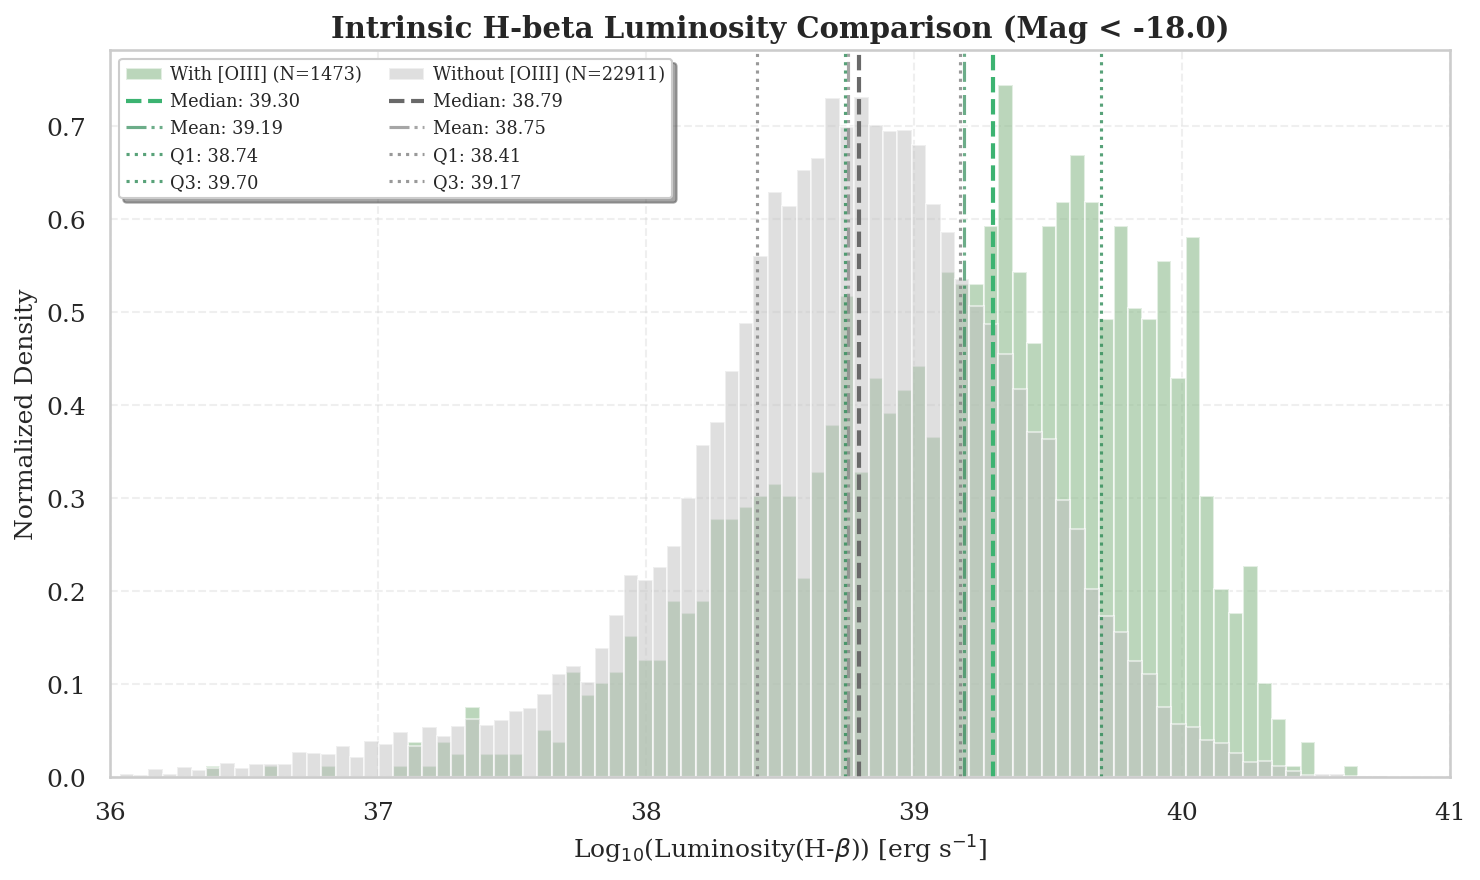

In [31]:
columna_flujo = 'H_BETA_FLUX'  
columna_z = 'Z' 
columna_lum_log = 'log_L_hbeta'
nombre_eje_lum = r'Log$_{10}$(Luminosity(H-$\beta$)) [erg s$^{-1}$]'

# Solo procesamos el corte M_B > -18
if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    # Extraemos copias para no tocar los datos originales
    df_c = data['con_oiii'].copy()
    df_s = data['sin_oiii'].copy()
    
    # Convertimos a numérico
    # Usamos df_temp para no sobreescribir la variable global df
    for df_temp in [df_c, df_s]:
        df_temp[columna_flujo] = pd.to_numeric(df_temp[columna_flujo], errors='coerce')
        df_temp[columna_z] = pd.to_numeric(df_temp[columna_z], errors='coerce')
        
    # Solo flujos positivos Y redshift positivo
    # (Si z <= 0, la distancia da error o cero, y arruina el logaritmo)
    mask_c = (df_c[columna_flujo] > 0) & (df_c[columna_z] > 0)
    mask_s = (df_s[columna_flujo] > 0) & (df_s[columna_z] > 0)
    
    df_c = df_c[mask_c].copy()
    df_s = df_s[mask_s].copy()
    
   
    # GRUPO 'CON OIII'
    # A) Flujo real en la Tierra (erg/s/cm2)
    flujo_real_c = df_c[columna_flujo] * 1e-17
    # B) Distancia de luminosidad en cm (usando Astropy)
    dl_cm_c = cosmo.luminosity_distance(df_c[columna_z]).to(u.cm).value
    # C) Luminosidad (erg/s) y su logaritmo
    lum_c = 4 * np.pi * (dl_cm_c**2) * flujo_real_c
    df_c[columna_lum_log] = np.log10(lum_c)
    
    # GRUPO 'SIN OIII'
    flujo_real_s = df_s[columna_flujo] * 1e-17
    dl_cm_s = cosmo.luminosity_distance(df_s[columna_z]).to(u.cm).value
    lum_s = 4 * np.pi * (dl_cm_s**2) * flujo_real_s
    df_s[columna_lum_log] = np.log10(lum_s)
    
    titulo_lum = f"Intrinsic H-beta Luminosity Comparison (Mag < {limit_mag})"
    
    plot_compare_dwarfs(df_c, df_s, 
                        column=columna_lum_log,
                        title=titulo_lum, 
                        xlabel=nombre_eje_lum,
                        show_stats=True,
                        xlims = (36, 41),
                        save_path = 'comp_lum_hbeta')

### Comparamos la anchura equivalente de H beta
Tenemos en cuenta que en este catálogo, la emisión se expresa como en anchura equivalente negativa. Cambiamos el signo para que nos sea más intuitivo, y tenga la convención moderna.

Figura guardada en: comp_rew_hbeta


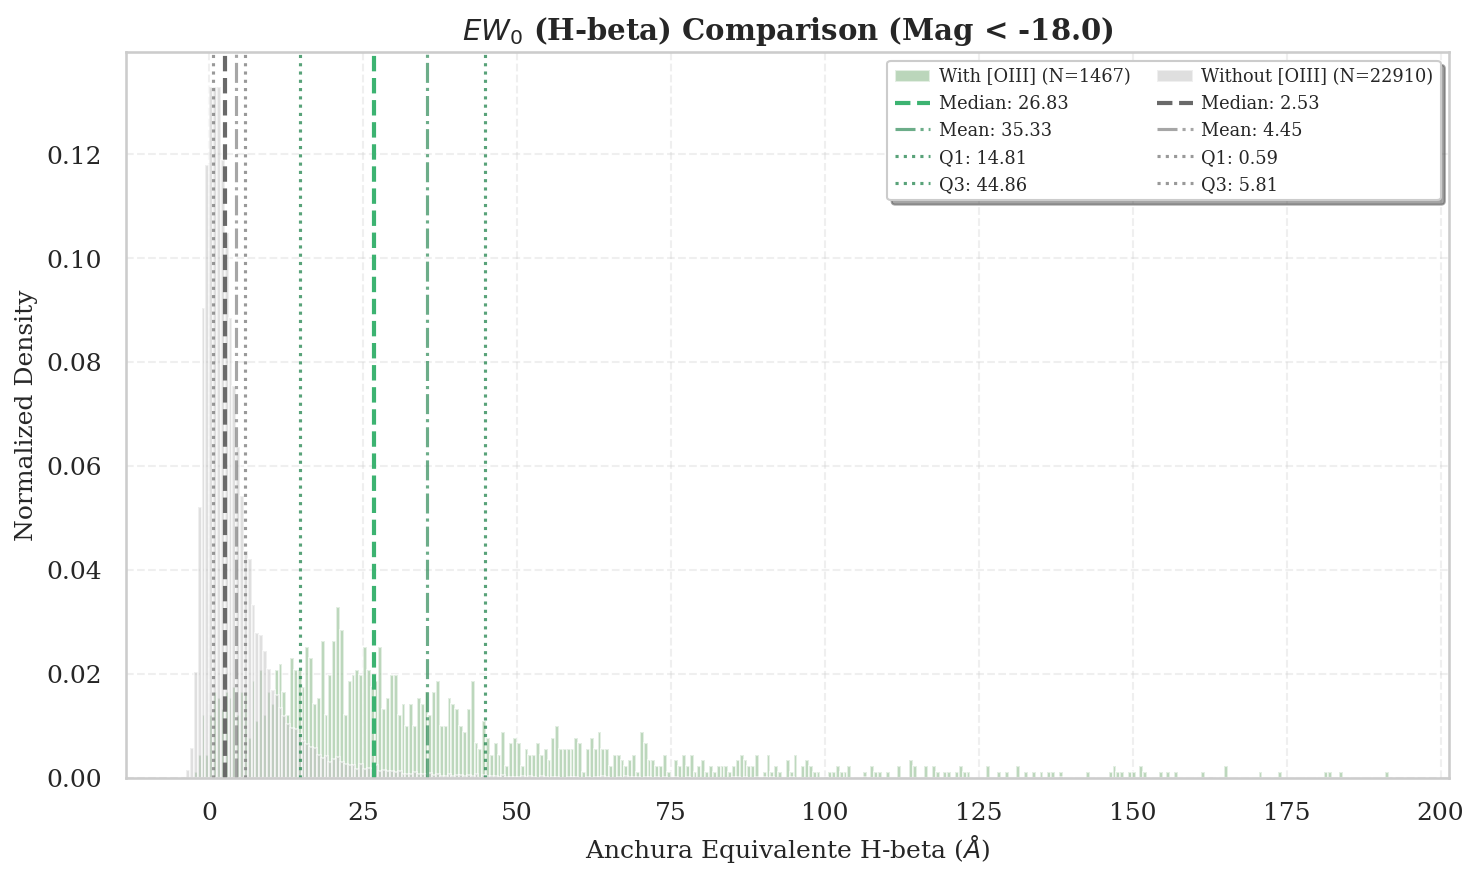

In [32]:
columna_original = 'H_BETA_REQW'  # Rest EQW es la anchura corregida de la expansión del universo
nombre_eje = 'Anchura Equivalente H-beta ($Å$)'

# Solo procesamos el corte M_B > -18
if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    df_c = data['con_oiii'].copy()
    df_s = data['sin_oiii'].copy()
    
    df_c[columna_original] = pd.to_numeric(df_c[columna_original], errors='coerce')
    df_s[columna_original] = pd.to_numeric(df_s[columna_original], errors='coerce') 
  

    titulo = f"$EW_0$ (H-beta) Comparison (Mag < {limit_mag})"
    
    plot_compare_dwarfs(df_c, df_s, 
                        column=columna_original,
                        title=titulo, 
                        xlabel=nombre_eje,
                        show_stats=True,
                        save_path= 'comp_rew_hbeta') # 30 barras suele verse bien en lineal

### Comparamos la anchura equivalente de [OIII]4363

Figura guardada en: comp_rew_oiii


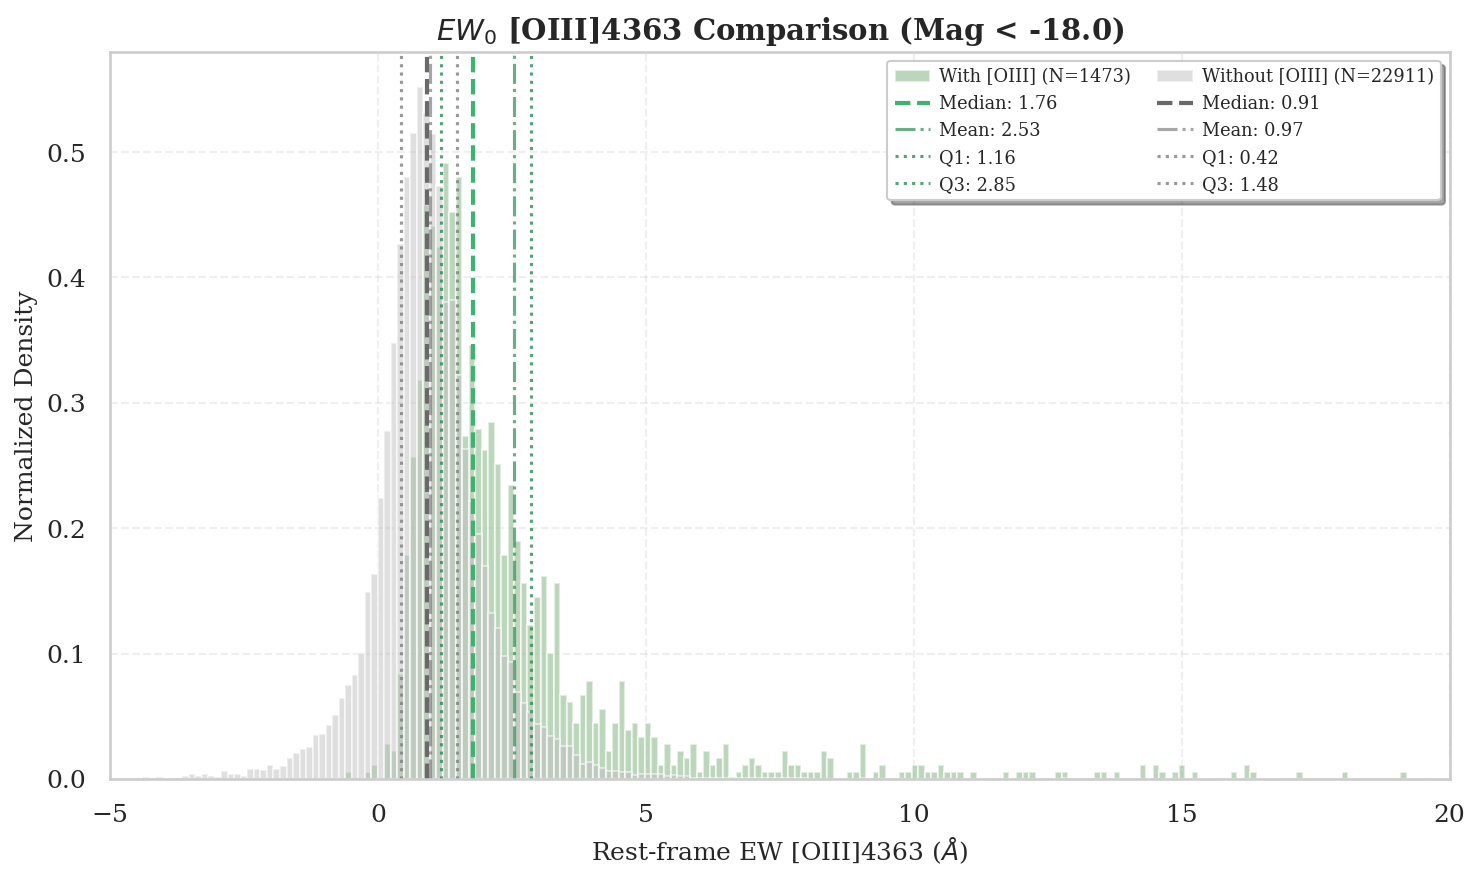

In [34]:
columna_original = 'OIII_4363_REQW'  # Rest EQW es la anchura corregida de la expansión del universo
nombre_eje = 'Rest-frame EW [OIII]4363 ($Å$)'


if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]

    df_c = data['con_oiii'].copy()
    df_s = data['sin_oiii'].copy()
    
    df_c[columna_original] = pd.to_numeric(df_c[columna_original], errors='coerce')
    df_s[columna_original] = pd.to_numeric(df_s[columna_original], errors='coerce')
  

    titulo = f"$EW_0$ [OIII]4363 Comparison (Mag < {limit_mag})"
    plot_compare_dwarfs(df_c, df_s, 
                        column=columna_original,
                        title=titulo, 
                        xlabel=nombre_eje,
                        show_stats=True,
                        xlims=(-5,20),
                        save_path = 'comp_rew_oiii') 

### COmparamos el radio

El objetivo de esta sección es comparar el tamaño físico (radio en kpc) de las galaxias enanas con fuerte emisión de [OIII] (candidatas a *Green Peas* o análogas locales) frente a las enanas sin esta emisión. Físicamente, esperamos que estas galaxias sean sistemas muy compactos, con radios típicos entre **0.5 y 10 kpc**.



Sin embargo, la exploración inicial de los datos crudos del SDSS (*Sloan Digital Sky Survey*) reveló la presencia de valores físicamente imposibles en la muestra, incluyendo galaxias con radios aparentes de cientos de kiloparsecs (kpc).

Al investigar la causa de estas anomalías mediante inspección visual y análisis cruzado de catálogos, identificamos varios problemas inherentes al algoritmo fotométrico (el *pipeline*) del SDSS:

* **Artefactos en la Banda Verde (g):** El radio medido en el filtro `g` (`petroRad_g`) presentaba valores extremos para ciertos objetos. Esto suele ocurrir cuando el programa confunde a la galaxia enana con el halo de una estrella brillante superpuesta en nuestra propia galaxia, o debido a rayos cósmicos. La solución metodológica fue cambiar la medición al **filtro rojo (r)** (`petroRad_r`), que es la banda principal y más estable del SDSS para determinar la morfología.
* **Códigos de Error del Catálogo (-1000):** Encontramos valores fotométricos de `-1000.0`. En la base de datos del SDSS, este no es un número real, sino una "bandera" (flag) que indica que el algoritmo matemático fue incapaz de converger y calcular el perfil de luz del objeto.
* **Incertidumbres Gigantes (`petroRadErr`):** Incluso al cambiar de banda y eliminar los códigos de error, algunas galaxias presentaban tamaños aparentemente normales pero con errores asociados desproporcionados (incertidumbres mayores que la propia medida). Esto indica que el ajuste de Petrosian no es fiable.

**Estrategia de Limpieza**
Para asegurar que las distribuciones comparativas sean robustas y representen galaxias reales, aplicamos una estricta máscara de control de calidad antes de calcular el tamaño físico. Exigimos:
1.  Un radio de Petrosian lógico: `0 < petroRad_r < 30` segundos de arco (eliminando monstruos estelares y valores negativos).
2.  Un error fotométrico controlado: `0 < petroRadErr_r < 2.0` segundos de arco (garantizando un ajuste confiable del perfil de luz).

Tras este filtrado, el ruido algorítmico desaparece, permitiéndonos observar la verdadera distribución física de las enanas emisoras y no emisoras.

In [36]:
def calcular_radio_fisico(df, col_radio_arcsec='petroRad_r', col_z='Z'):
    """
    Convierte un radio angular (arcsec) a físico (kpc) usando el redshift.
    """
    # Evitamos alertas de Pandas trabajando con una copia
    df_out = df.copy()
    
    # Limpieza básica: Z debe ser positivo y el radio debe existir
    df_out[col_z] = pd.to_numeric(df_out[col_z], errors='coerce')
    df_out[col_radio_arcsec] = pd.to_numeric(df_out[col_radio_arcsec], errors='coerce')
    
    # Filtramos cosas sin sentido físico (Z <= 0 o radios nulos)
    mask = (df_out[col_z] > 0.001) & (df_out[col_radio_arcsec] > 0)
    df_out = df_out[mask].copy()
    
    # Calculamos cuántos kpc son 1 segundo de arco a ese redshift
    # kcp_proper_per_arcmin devuelve kpc/arcmin. Dividimos por 60 para arcsec.
    scale_factor = cosmo.kpc_proper_per_arcmin(df_out[col_z].values).value / 60.0
    
    # Multiplicamos: Radio (") * Escala (kpc/")
    df_out['radio_kpc'] = df_out[col_radio_arcsec] * scale_factor
    
    return df_out

Figura guardada en: comp_rad_r


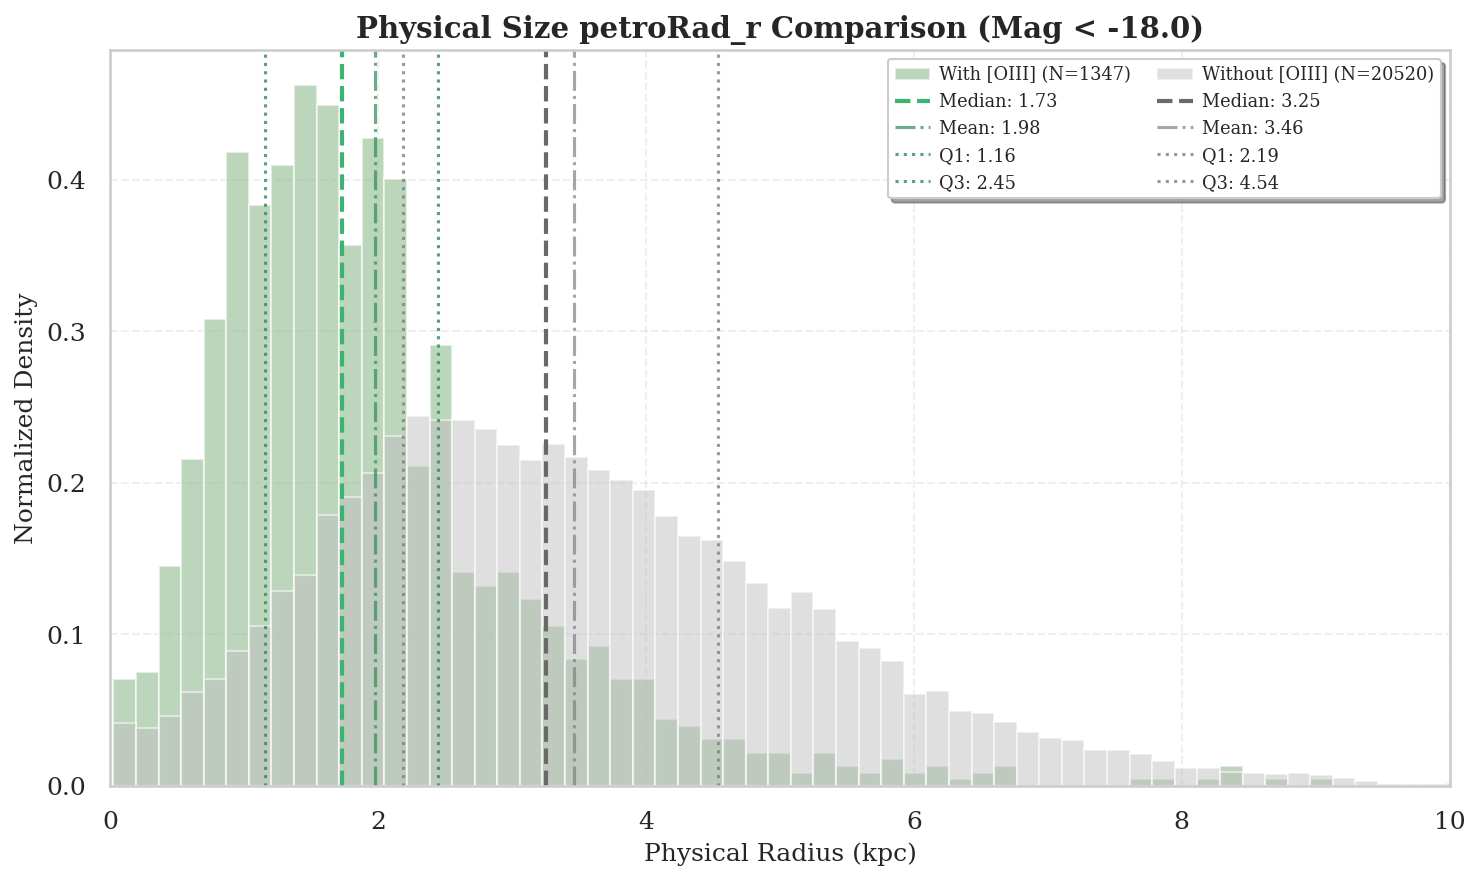

In [37]:
variable_original = 'petroRad_r'
variable_error = 'petroRadErr_r' 
variable_kpc = 'radio_kpc'
nombre_eje = 'Physical Radius (kpc)'

# Solo procesamos el corte M_B > -18
if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    
    df_c_raw = data['con_oiii'].copy()
    df_s_raw = data['sin_oiii'].copy()
    
    # máscara
    for df_temp in [df_c_raw, df_s_raw]:
        # Forzamos numérico 
        df_temp[variable_original] = pd.to_numeric(df_temp[variable_original], errors='coerce')
        if variable_error in df_temp.columns:
            df_temp[variable_error] = pd.to_numeric(df_temp[variable_error], errors='coerce')
            
    # Máscara 1: -1000 de error y más de 30 arcsec
    mask_c = (df_c_raw[variable_original] > 0) & (df_c_raw[variable_original] < 30)
    mask_s = (df_s_raw[variable_original] > 0) & (df_s_raw[variable_original] < 30)
    
    # Máscara 2: errores gigantes
    if variable_error in df_c_raw.columns:
        # Exigimos un error mayor que 0 (evita más flags raros) y menor que 2 arcsec
        mask_c = mask_c & (df_c_raw[variable_error] > 0) & (df_c_raw[variable_error] < 2.0)
        mask_s = mask_s & (df_s_raw[variable_error] > 0) & (df_s_raw[variable_error] < 2.0)
        
    # Aplicamos
    df_c_clean = df_c_raw[mask_c]
    df_s_clean = df_s_raw[mask_s]

    # Procesamos y convertimos cada grupo
    df_c = calcular_radio_fisico(df_c_clean, col_radio_arcsec=variable_original)
    df_s = calcular_radio_fisico(df_s_clean, col_radio_arcsec=variable_original)
    
    # Verificación de seguridad (por si el filtrado vació el dataframe)
    if len(df_c) < 10 or len(df_s) < 10:
        print(f"Saltando mag {limit_mag}: insuficientes datos tras limpiar radios dudosos.")
    else:
        # Solo graficamos si entra en el ELSE (si hay datos suficientes)
        titulo = f"Physical Size petroRad_r Comparison (Mag < {limit_mag})"
        plot_compare_dwarfs(df_c, df_s, column=variable_kpc, title=titulo, 
                            xlabel=nombre_eje, show_stats=True, xlims=(0,10), save_path='comp_rad_r')

Figura guardada en: comp_rad_g


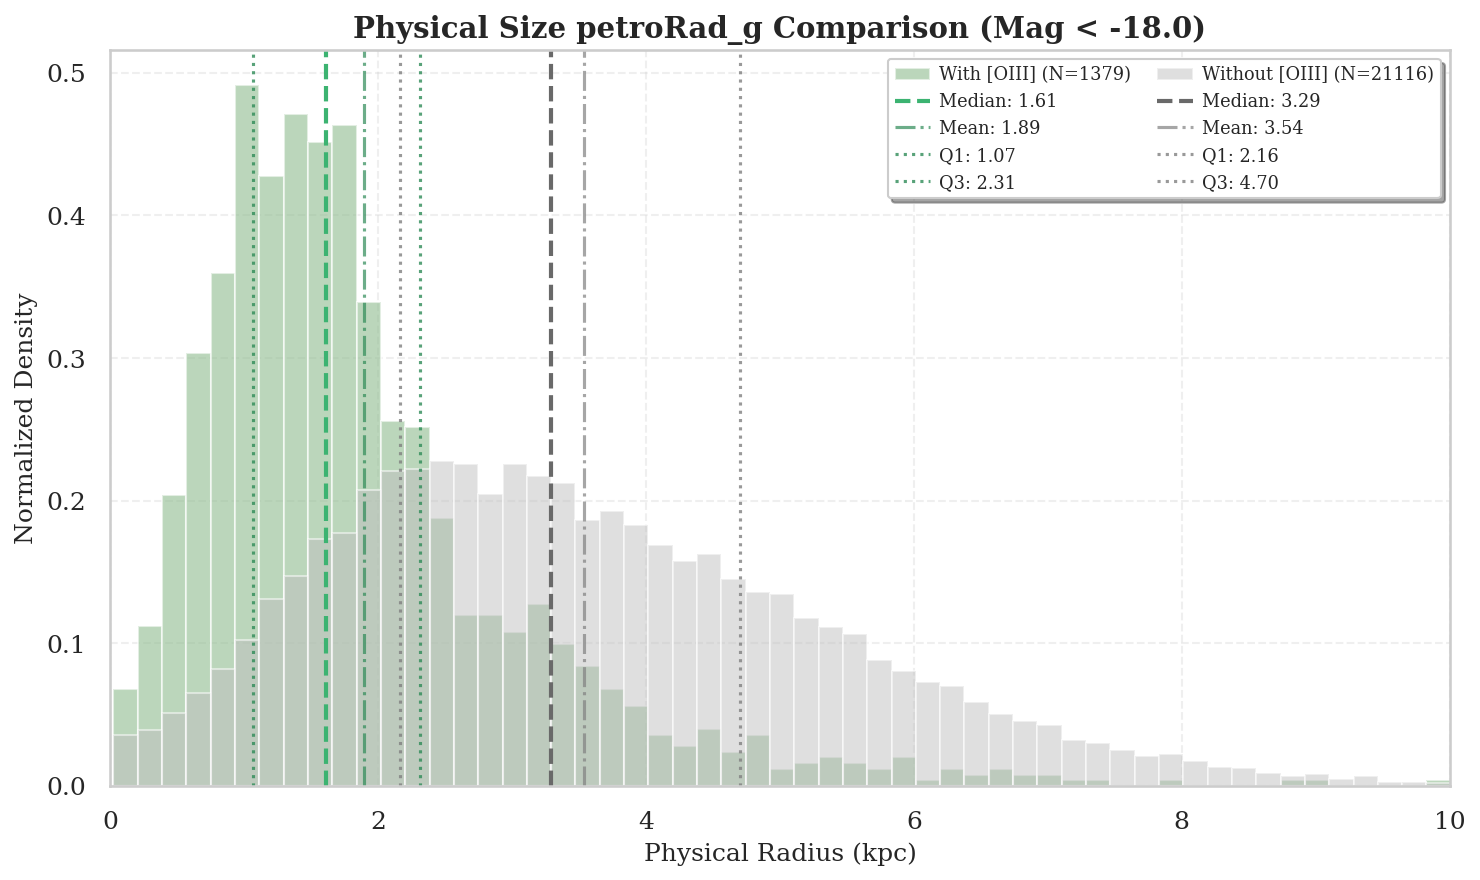

In [38]:
variable_original = 'petroRad_g'
variable_error = 'petroRadErr_g' 
variable_kpc = 'radio_kpc'
nombre_eje = 'Physical Radius (kpc)'

# Solo procesamos el corte M_B > -18
if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    
    df_c_raw = data['con_oiii'].copy()
    df_s_raw = data['sin_oiii'].copy()
    
    for df_temp in [df_c_raw, df_s_raw]:
        # Forzamos numérico 
        df_temp[variable_original] = pd.to_numeric(df_temp[variable_original], errors='coerce')
        if variable_error in df_temp.columns:
            df_temp[variable_error] = pd.to_numeric(df_temp[variable_error], errors='coerce')
            
    # Máscara 1: -1000 de error y más de 30 arcsec
    mask_c = (df_c_raw[variable_original] > 0) & (df_c_raw[variable_original] < 30)
    mask_s = (df_s_raw[variable_original] > 0) & (df_s_raw[variable_original] < 30)
    
    # Máscara 2: errores gigantes
    if variable_error in df_c_raw.columns:
        # Exigimos un error mayor que 0 (evita flags raros) y menor que 2 arcsec
        mask_c = mask_c & (df_c_raw[variable_error] > 0) & (df_c_raw[variable_error] < 2.0)
        mask_s = mask_s & (df_s_raw[variable_error] > 0) & (df_s_raw[variable_error] < 2.0)
        
    # Aplicamos
    df_c_clean = df_c_raw[mask_c]
    df_s_clean = df_s_raw[mask_s]

    df_c = calcular_radio_fisico(df_c_clean, col_radio_arcsec=variable_original)
    df_s = calcular_radio_fisico(df_s_clean, col_radio_arcsec=variable_original)
    
    if len(df_c) < 10 or len(df_s) < 10:
        print(f"Saltando mag {limit_mag}: insuficientes datos tras limpiar radios dudosos.")
    else:
        # Solo graficamos si entra en el ELSE (si hay datos suficientes)
        titulo = f"Physical Size petroRad_g Comparison (Mag < {limit_mag})"
        plot_compare_dwarfs(df_c, df_s, column=variable_kpc, title=titulo, 
                            xlabel=nombre_eje, show_stats=True, xlims=(0,10), save_path='comp_rad_g')

In [39]:
# Definimos las columnas clave para el diagnóstico
cols_inspeccion = [
    'SPECOBJID', 
    'LGM_TOT_P50', 
    'Z',
    'petroRad_r', 
    'petroRadErr_r', 
    'petroRadErr_g', 
    'petroRadErr_i'
]

# Elegimos la columna por la que vamos a ordenar los peores errores
col_orden = 'petroRadErr_r' 

# Solo procesamos el corte M_B > -18
if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    print(f"Revisión de errores de radio para magnitud < {limit_mag}")
    
    # Recorremos los dos subgrupos
    for nombre_sub, key_sub in [("CON [OIII] (Green Peas / Emisoras)", 'con_oiii'), 
                                ("SIN [OIII] (Enanas normales)", 'sin_oiii')]:
        
        # Hacemos una copia para no alterar los datos originales
        df_sub = data[key_sub].copy()
        
        # Filtramos qué columnas existen 
        cols_presentes = [c for c in cols_inspeccion if c in df_sub.columns]
        
        if df_sub.empty:
            print(f"\n--- {nombre_sub}: No hay datos ---")
            continue
            
        if col_orden in df_sub.columns:
            # Aseguramos que el error sea numérico antes de ordenar
            df_sub[col_orden] = pd.to_numeric(df_sub[col_orden], errors='coerce')
            
            # Extraemos el top 10 de peores incertidumbres
            top_errores = df_sub.nlargest(10, col_orden).copy()
            
            # Formateamos del ID a número entero limpio
            if 'SPECOBJID' in top_errores.columns:
                top_errores['SPECOBJID'] = top_errores['SPECOBJID'].apply(lambda x: f"{int(float(x))}" if pd.notnull(x) else x)
            
            print(f"\nTOP 10 MAYOR INCERTIDUMBRE - {nombre_sub}")
            display(top_errores[cols_presentes])
        else:
            print(f"\nATENCIÓN: Falta la columna {col_orden} en el subgrupo {nombre_sub}.")

Revisión de errores de radio para magnitud < -18.0

TOP 10 MAYOR INCERTIDUMBRE - CON [OIII] (Green Peas / Emisoras)


,SPECOBJID,LGM_TOT_P50,Z,petroRad_r,petroRadErr_r,petroRadErr_g,petroRadErr_i
218321,2223789267857991680,6.062132,0.001977,84.888480,26.763130,30.287110,22.550990
216238,2191153008899811328,6.486115,0.001708,62.721180,21.752250,11.584890,7.678990
188079,1890491549536512000,8.555203,0.008260,39.238200,14.364150,14.428650,10.244460
220128,2241828125669353472,6.977575,0.011065,8.695127,12.442110,14.188970,9.701778
32841,514619852204304384,6.130968,0.004324,46.740280,9.698359,8.666626,8.449520
308581,3242749312395929600,8.841714,0.003742,42.043790,8.742680,7.827394,6.937087
279938,2835143579964303360,7.831243,0.007013,11.550790,8.168144,0.334024,0.548314
213829,2169760084173809664,9.066053,0.014582,18.085930,7.824324,10.023780,5.541280
245891,2475966104992770048,8.547307,0.008462,13.837180,7.541295,1.383862,8.258990
105249,1073129161595316224,7.944942,0.004119,14.217340,7.353592,7.041831,7.785579



TOP 10 MAYOR INCERTIDUMBRE - SIN [OIII] (Enanas normales)


,SPECOBJID,LGM_TOT_P50,Z,petroRad_r,petroRadErr_r,petroRadErr_g,petroRadErr_i
101408,1025804257242146816,8.552482,0.013730,50.09359,49.94486,-1000.000000,19.455260
293048,2978141393274300416,8.103732,0.001376,95.16093,43.61225,72.568950,45.609630
279109,2830621007704778752,7.578972,0.011969,37.27412,37.14071,13.550920,-1000.000000
40820,570917603908806656,8.959250,0.003324,92.68367,32.31208,19.465230,17.349290
272737,2797881129774901248,9.584579,0.003743,70.95512,31.83843,27.095670,23.061970
279207,2830686978402445312,9.182113,0.014282,31.21056,31.08539,4.755244,29.069320
9794,354807207503620096,7.772282,0.006395,65.75836,29.83825,14.502810,10.754330
251940,2513073527465207808,9.538062,0.003629,54.14465,28.87114,4.233192,28.890380
55112,659882932466378752,6.206852,0.005269,51.93822,28.09812,24.429520,2.967063
17623,425685583424153600,8.526227,0.005878,52.91324,27.95830,0.935633,1.017576


In [42]:
#  OUTLIERS DE RADIO
#el límite -18.0, grupo 'sin_oiii'
limite_actual = list(results_dwarf.keys())[0]

# Recalculamos el radio físico para asegurar que tenemos la columna
df_revisar = calcular_radio_fisico(results_dwarf[limite_actual]['sin_oiii'], col_radio_arcsec='petroRad_r')

# Extraemos el Top 10 de galaxias con radio más grande
top_10_gigantes = df_revisar.nlargest(10, 'radio_kpc')

# Columnas clave para entender el error del telescopio
cols_diagnostico = ['SPECOBJID', 'radio_kpc', 'petroRad_r', 'petroRadErr_g', 'Z']
cols_mostrar = [c for c in cols_diagnostico if c in top_10_gigantes.columns]

print(f"DIAGNÓSTICO: (Mag < {limite_actual}) ")
print(top_10_gigantes[cols_mostrar])

inspeccionar_galaxias_spec(top_10_gigantes, n=10)

DIAGNÓSTICO: (Mag < -18.0) 
                  SPECOBJID   radio_kpc  petroRad_r  petroRadErr_g         Z
262306  2648200207027693568  105.626760   258.39690       1.522923  0.020177
248092  2491700395223574528  102.427587   166.56150   -1000.000000  0.030742
285439  2911611588777633792   81.028314    50.67992       0.770560  0.085226
287429  2922873887018477568   79.870593   166.53090   -1000.000000  0.023776
292960  2978067725995239424   68.874277    43.77382   -1000.000000  0.083726
168635  1676546375329802240   50.373502   106.73780   -1000.000000  0.023384
170075  1690032447766423552   41.340574    27.92340   -1000.000000  0.078286
283313  2898122503824107520   36.919282    27.92047       0.679181  0.069182
69700    748759208551278592   31.306632    27.92255   -1000.000000  0.057887
229738  2365612526026123264   30.072355    43.77104   -1000.000000  0.034500
Inspección visual (SDSS SKYSERVER) - 10 objetos

Datos de la muestra
          SPECOBJID         RA        DEC        Z  mode

### Comparamos el color (g-r)

Figura guardada en: comp_color


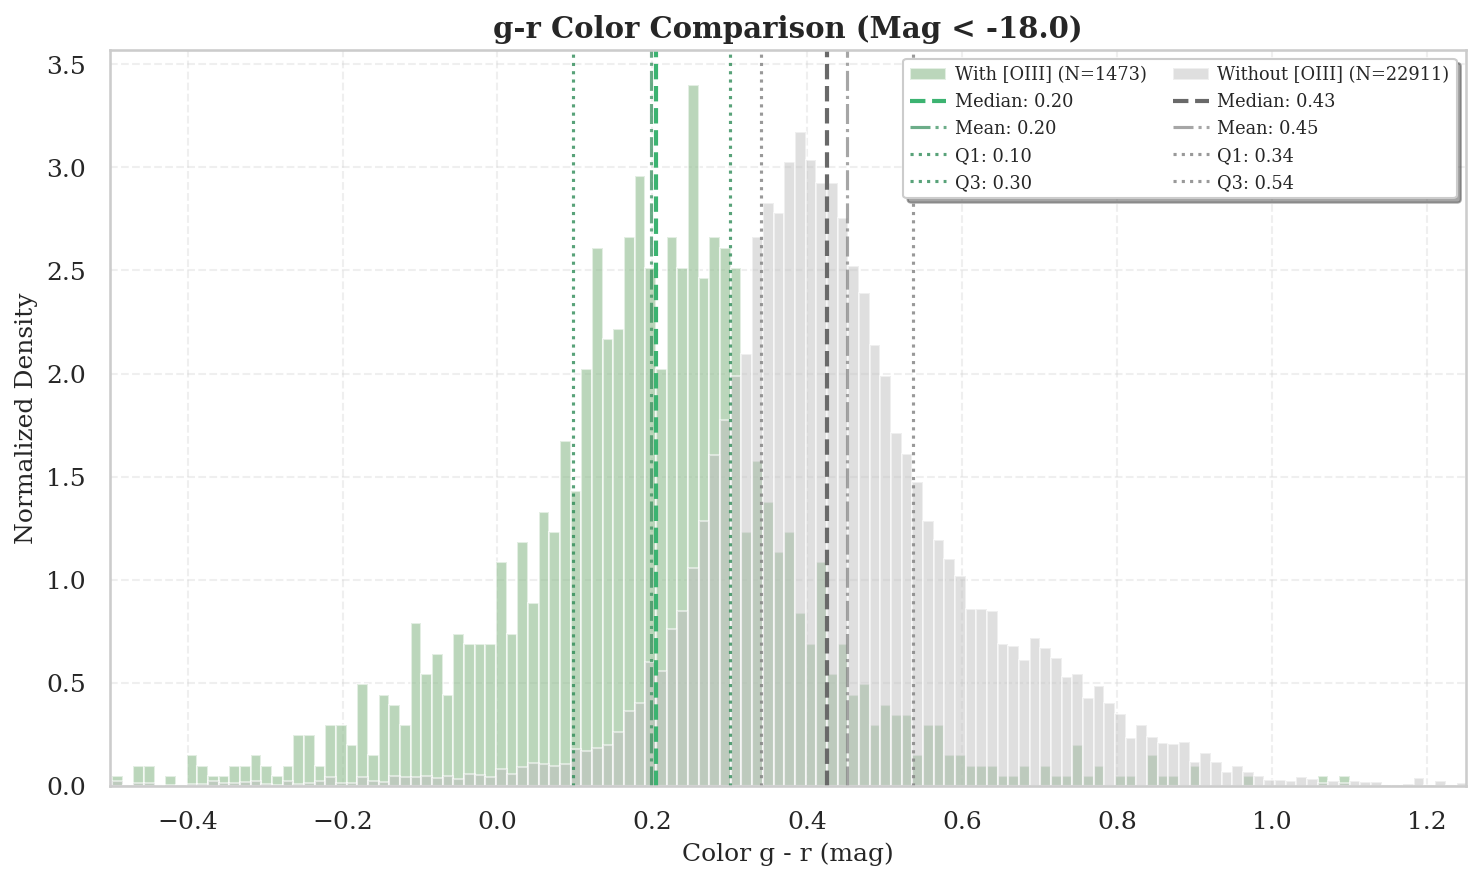

In [43]:
# Nombre que le daremos a la nueva columna en el DataFrame
nombre_columna_nueva = 'Color_g_r'
nombre_etiqueta = 'Color g - r (mag)'

# Iteramos sobre el diccionario de resultados
# Solo procesamos el corte M_B > -18
if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    # extraemos copias para no afectar al diccionario original 
    df_c = data['con_oiii'].copy()
    df_s = data['sin_oiii'].copy()
    
    # CÁLCULO DE LA VARIABLE (Aquí hacemos la resta matemática de las columnas)
    # g - r
    df_c[nombre_columna_nueva] = df_c['modelMag_g'] - df_c['modelMag_r']
    df_s[nombre_columna_nueva] = df_s['modelMag_g'] - df_s['modelMag_r']
    
    titulo = f"g-r Color Comparison (Mag < {limit_mag})"
    
    # 3. Graficamos
    plot_compare_dwarfs(df_c, df_s, 
                        column=nombre_columna_nueva, 
                        title=titulo, 
                        xlabel=nombre_etiqueta,
                        show_stats=True,
                        xlims=(-0.5,1.25),
                        save_path='comp_color') # Activamos estadísticas completas

### Comparamos el break de 4000

Figura guardada en: comp_d4000


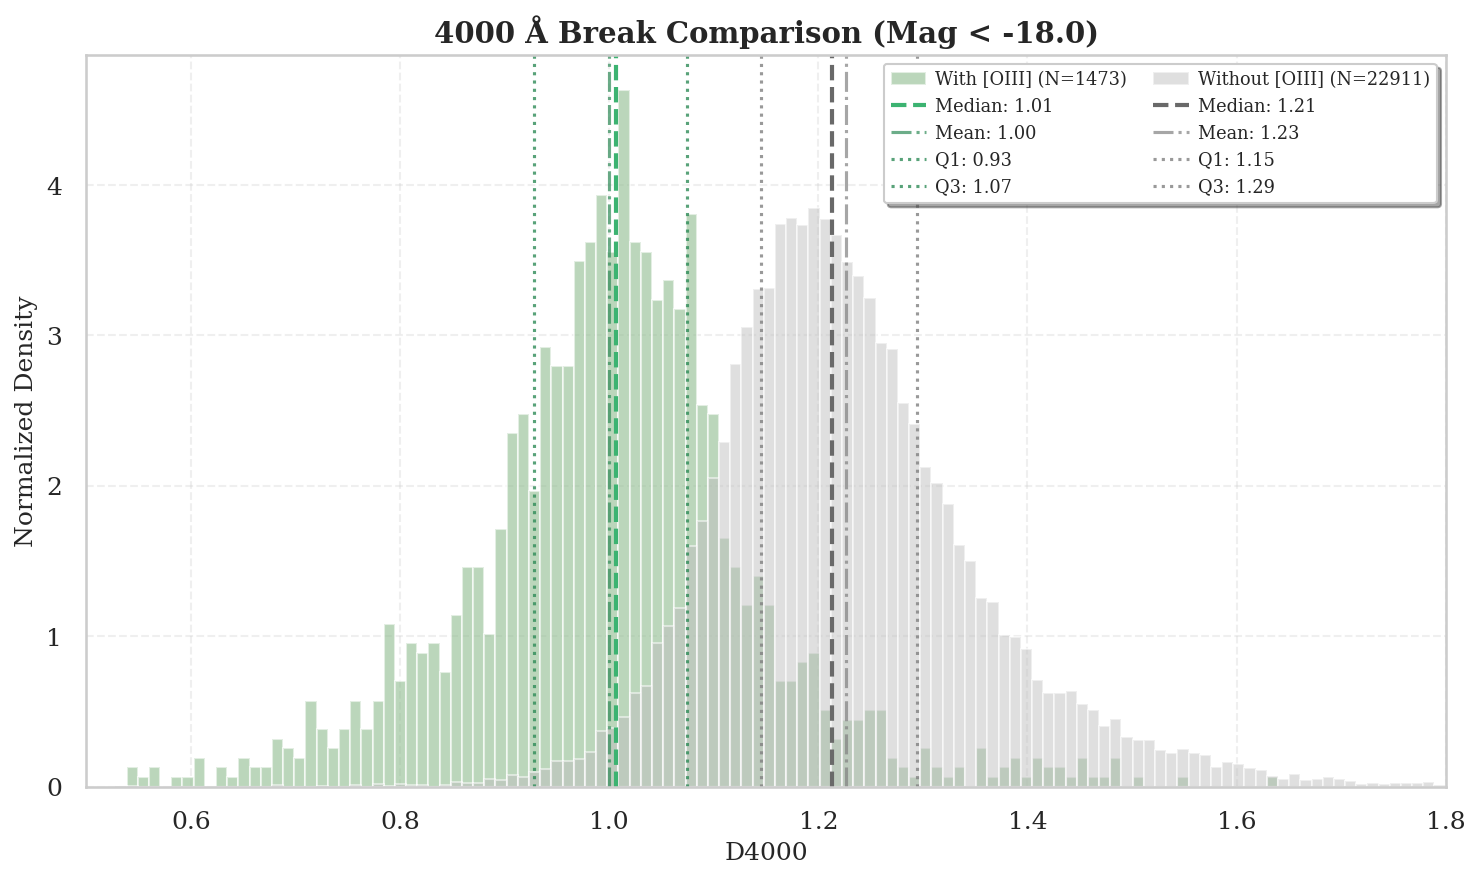

In [44]:
columna_original = 'D4000_N'  
nombre_eje = 'D4000'

if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]

    df_c = data['con_oiii'].copy()
    df_s = data['sin_oiii'].copy()
 
    df_c[columna_original] = pd.to_numeric(df_c[columna_original], errors='coerce')
    df_s[columna_original] = pd.to_numeric(df_s[columna_original], errors='coerce') 
  
    titulo = f"4000 Å Break Comparison (Mag < {limit_mag})"
    
    plot_compare_dwarfs(df_c, df_s, 
                        column=columna_original,
                        title=titulo, 
                        xlabel=nombre_eje,
                        show_stats=True,
                        xlims=(0.5,1.8),
                        save_path= 'comp_d4000')

### Comparamos el redshift

Figura guardada en: comp_z


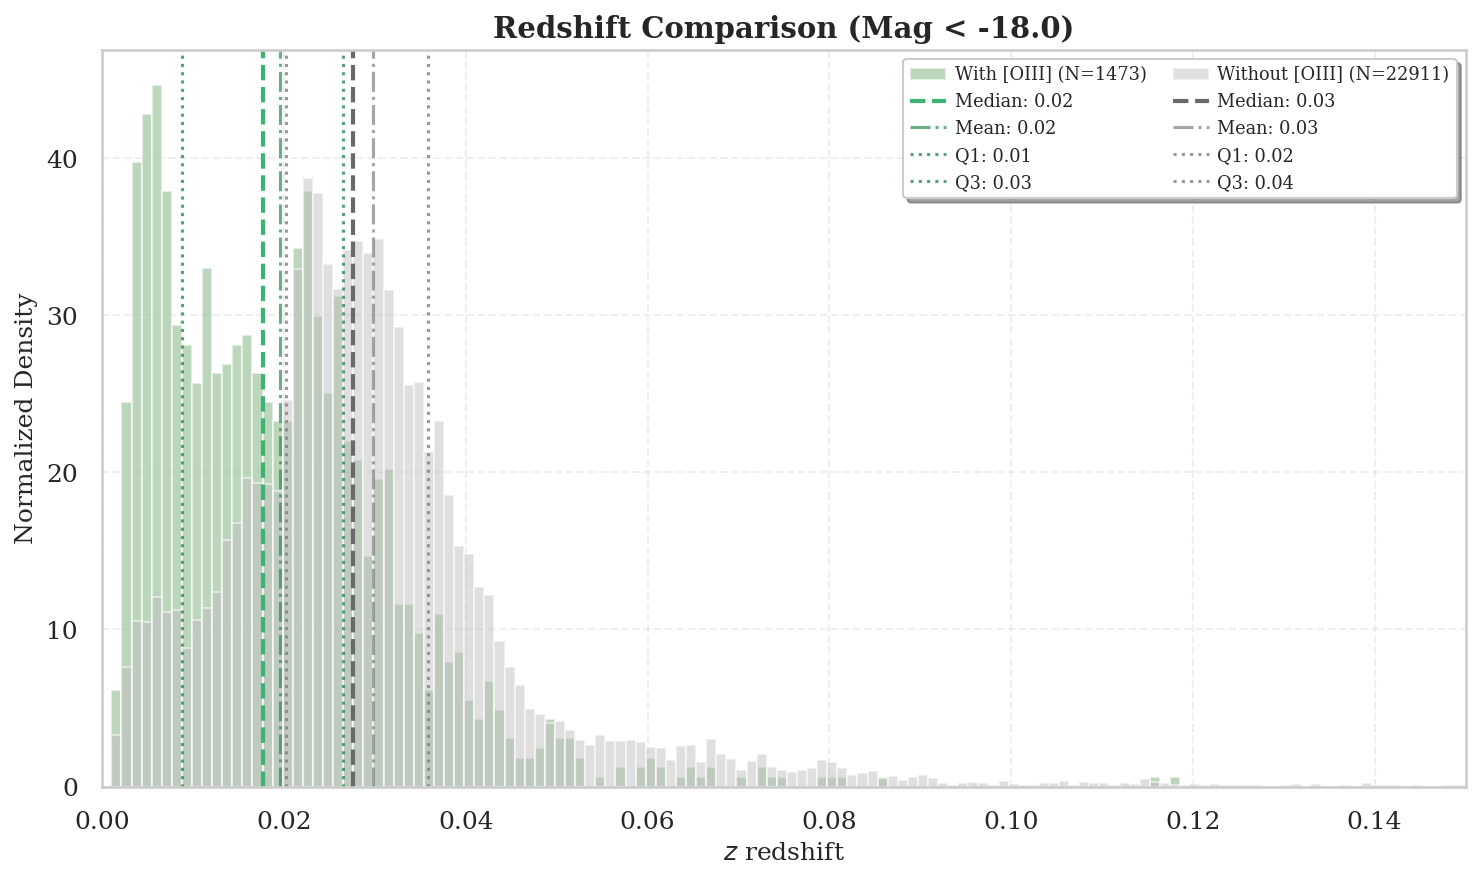

In [47]:
columna_original = 'Z'  
nombre_eje = r'$z$ redshift'

if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    
    df_c = data['con_oiii'].copy()
    df_s = data['sin_oiii'].copy()
    
    df_c[columna_original] = pd.to_numeric(df_c[columna_original], errors='coerce')
    df_s[columna_original] = pd.to_numeric(df_s[columna_original], errors='coerce') 
  

    titulo = f"Redshift Comparison (Mag < {limit_mag})"
    plot_compare_dwarfs(df_c, df_s, 
                        column=columna_original,
                        title=titulo, 
                        xlabel=nombre_eje,
                        show_stats=True,
                        xlims=(0,0.15),
                        save_path= 'comp_z') 

### Comparamos índices de Lick

Figura guardada en: comp_Lick_Hgamma


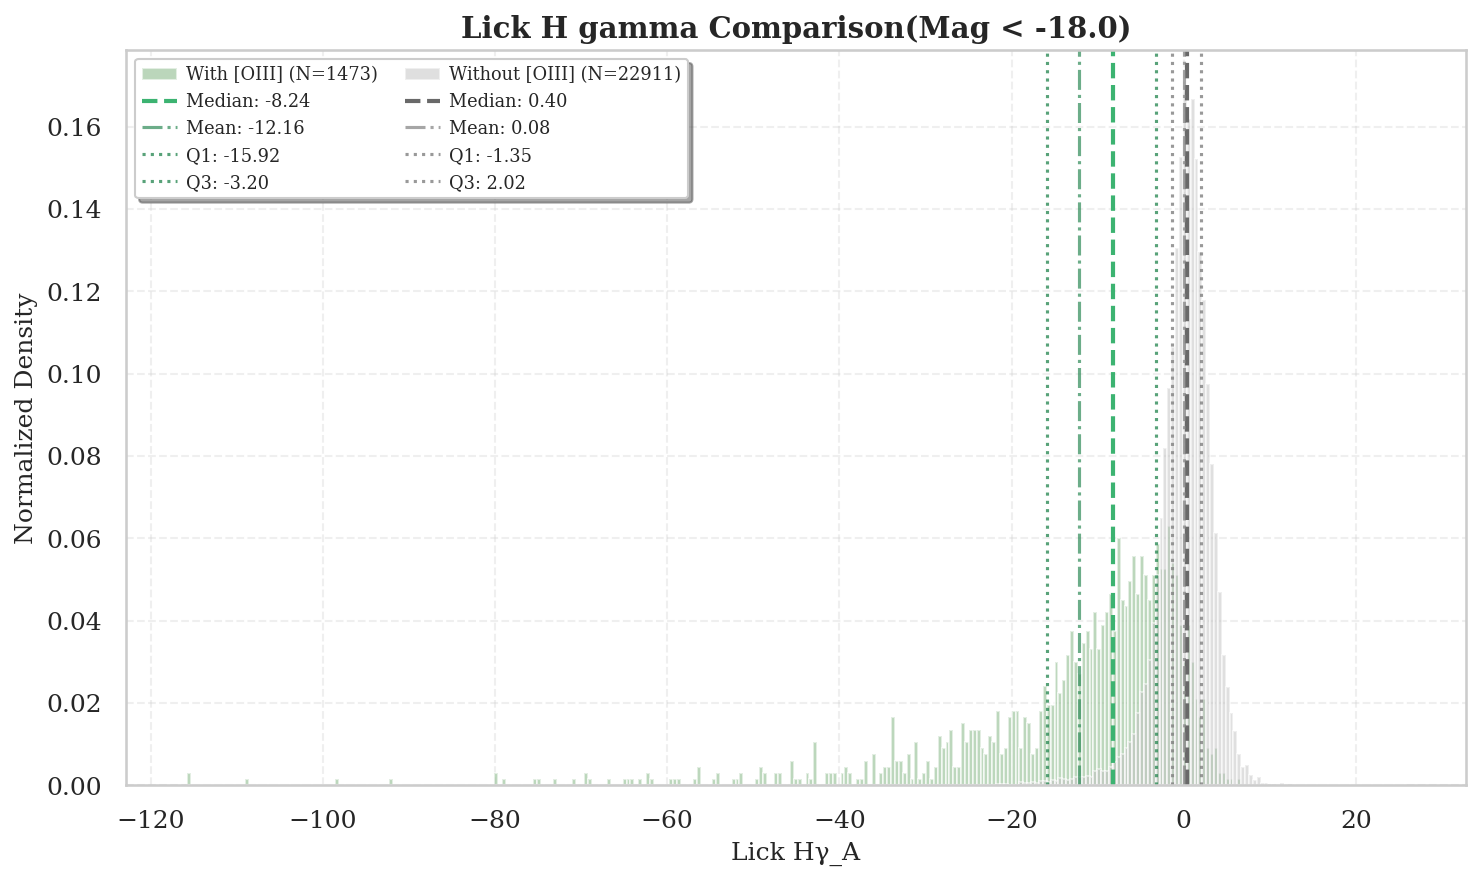

In [51]:
columna_original = 'LICK_HG_A'
nombre_eje = r'Lick Hγ_A'

if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]

    df_c = data['con_oiii'].copy()
    df_s = data['sin_oiii'].copy()
    
    df_c[columna_original] = pd.to_numeric(df_c[columna_original], errors='coerce')
    df_s[columna_original] = pd.to_numeric(df_s[columna_original], errors='coerce') 
  

    titulo = f"Lick H gamma Comparison(Mag < {limit_mag})"
    plot_compare_dwarfs(df_c, df_s, 
                        column=columna_original,
                        title=titulo, 
                        xlabel=nombre_eje,
                        show_stats=True,
                        #xlims=(0,0.1),
                        save_path= 'comp_Lick_Hgamma') 

Figura guardada en: comp_Lick_Mg2


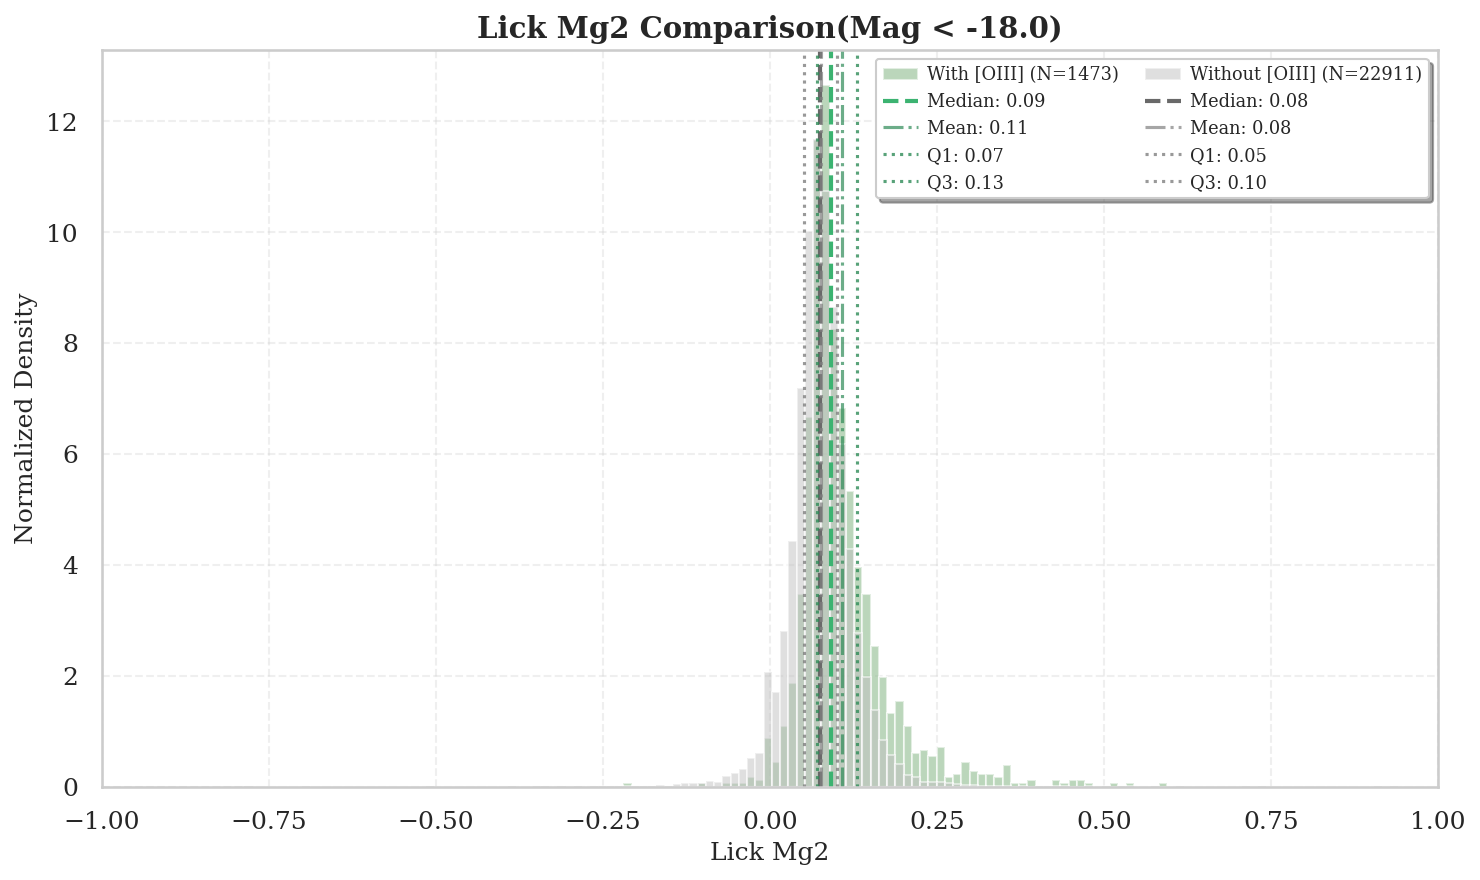

In [53]:
columna_original = 'LICK_MG2'  
nombre_eje = r'Lick Mg2'


if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]

    df_c = data['con_oiii'].copy()
    df_s = data['sin_oiii'].copy()
    
    df_c[columna_original] = pd.to_numeric(df_c[columna_original], errors='coerce')
    df_s[columna_original] = pd.to_numeric(df_s[columna_original], errors='coerce') 
  

    titulo = f"Lick Mg2 Comparison(Mag < {limit_mag})"
    plot_compare_dwarfs(df_c, df_s, 
                        column=columna_original,
                        title=titulo, 
                        xlabel=nombre_eje,
                        show_stats=True,
                        xlims=(-1,1),
                        save_path= 'comp_Lick_Mg2') 

Figura guardada en: comp_Lick_Hbeta


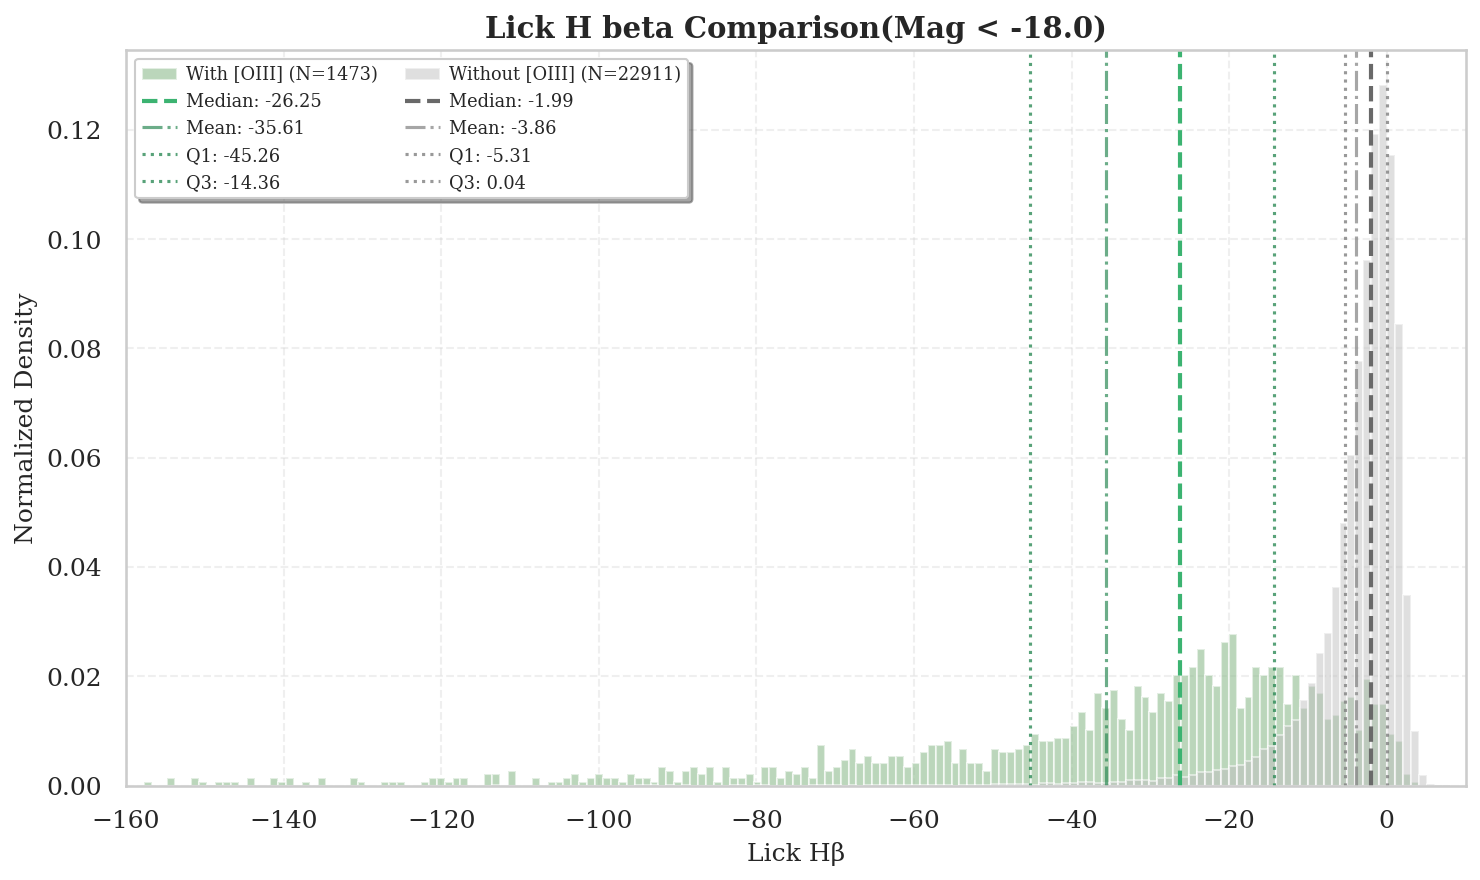

In [54]:
columna_original = 'LICK_HB'  
nombre_eje = r'Lick Hβ'


if True:
    limit_mag, data = -18.0, results_dwarf[-18.0]
    
    df_c = data['con_oiii'].copy()
    df_s = data['sin_oiii'].copy()
    df_c[columna_original] = pd.to_numeric(df_c[columna_original], errors='coerce')
    df_s[columna_original] = pd.to_numeric(df_s[columna_original], errors='coerce') 

    titulo = f"Lick H beta Comparison(Mag < {limit_mag})"
    
    plot_compare_dwarfs(df_c, df_s, 
                        column=columna_original,
                        title=titulo, 
                        xlabel=nombre_eje,
                        show_stats=True,
                        xlims=(-160,10),
                        save_path= 'comp_Lick_Hbeta') 

## 3. Unimos 

In [55]:
from astroquery.vizier import Vizier

Vizier.ROW_LIMIT = -1
catalogo = Vizier.get_catalogs("J/MNRAS/421/1043")

# Primero, ver qué claves tiene 
print(type(catalogo))
print(catalogo) # Muestra el índice con los nombres reales
print(catalogo.keys()) # Lista de nombres exactos

<class 'astroquery.utils.commons.TableList'>
TableList with 2 tables:
	'0:J/MNRAS/421/1043/table2' with 14 column(s) and 3165 row(s) 
	'1:J/MNRAS/421/1043/table5' with 15 column(s) and 194 row(s) 
['J/MNRAS/421/1043/table2', 'J/MNRAS/421/1043/table5']


In [56]:
# Cargamos las dos para inspeccionarlas
t2 = catalogo["J/MNRAS/421/1043/table2"].to_pandas()
t5 = catalogo["J/MNRAS/421/1043/table5"].to_pandas()

print("TABLE 2 (muestra completa HeII)")
print(t2.columns.tolist())
print(t2.head(3))

print("\nTABLE 5 (SF puras con HeII)")
print(t5.columns.tolist())
print(t5.head(3))

TABLE 2 (muestra completa HeII)
['RAJ2000', 'DEJ2000', 'sf', 'Plate', 'MJD', 'Fib', 'logHeII/Hb', 'log[NII]/Ha', 'Class', 'BPT', 'SN', 'WR', 'WRcl', 'Sloan']
       RAJ2000       DEJ2000 sf  Plate    MJD  Fib  logHeII/Hb  log[NII]/Ha  \
0  11 59 09.71  +00 00 06.78       285  51930  485       -0.93        -0.14   
1  15 30 26.32  +00 00 10.81       363  51989  400       -0.79        -0.31   
2  08 58 28.60  +00 01 24.49       470  51929  309       -0.84        -0.01   

  Class  BPT    SN      WR  WRcl  Sloan  
0   AGN  AGN  OKSN  Non-WR  <NA>  Sloan  
1   AGN  AGN  OKSN  Non-WR  <NA>  Sloan  
2   AGN  AGN  OKSN      WR     1  Sloan  

TABLE 5 (SF puras con HeII)
['Plate', 'MJD', 'Fib', 'z', 'RAJ2000', 'DEJ2000', 'ID', 'logHeII/Hb', 'log[NII]/Ha', 'e(O)', 'e_e(O)', 'WR', 'WRcl', 'OName', 'Sloan']
   Plate    MJD  Fib        z      RAJ2000       DEJ2000  ID  logHeII/Hb  \
0    752  52251  340  0.00291  00 09 53.09  +15 44 04.80  51       -1.35   
1    390  51900  291  0.09437  00 17 28.

In [58]:
# Partir del total de enanas (con Y sin OIII) 
df_todas_enanas = results_dwarf[-18.0]['total'].copy()

# Columnas nativas de identificación
df_todas_enanas['PLATE'] = df_todas_enanas['PLATEID'].astype(int)
df_todas_enanas['MJD']   = df_todas_enanas['MJD'].astype(int)
df_todas_enanas['FIBER'] = df_todas_enanas['FIBERID'].astype(int)

# Añadir etiqueta para saber de qué subgrupo viene cada objeto
mask_oiii = results_dwarf[-18.0]['con_oiii'].index
df_todas_enanas['tiene_oiii'] = df_todas_enanas.index.isin(mask_oiii)

print(f"Total enanas (con + sin OIII): {len(df_todas_enanas)}")
print(f"Con [OIII]4363:  {df_todas_enanas['tiene_oiii'].sum()}")
print(f"Sin [OIII]4363:  {(~df_todas_enanas['tiene_oiii']).sum()}")

Total enanas (con + sin OIII): 24384
Con [OIII]4363:  1473
Sin [OIII]4363:  22911


In [63]:
# Preparar t5_merge (igual que se hace con t2_merge) 
t5_merge = t5.rename(columns={'Plate':'PLATE', 'MJD':'MJD', 'Fib':'FIBER'}).copy()
for col in ['PLATE', 'MJD', 'FIBER']:
    t5_merge[col] = t5_merge[col].astype(int)

# Merge con Shirazi table5 (SF con HeII) 
df_todas_heii = df_todas_enanas.merge(
    t5_merge,
    on=['PLATE', 'MJD', 'FIBER'],
    how='left',
    suffixes=('', '_shirazi')
)

# Merge con Shirazi table2 (muestra completa, para Class y BPT) 
t2_merge = t2.rename(columns={'Plate':'PLATE', 'MJD':'MJD', 'Fib':'FIBER'}).copy()
for col in ['PLATE', 'MJD', 'FIBER']:
    t2_merge[col] = t2_merge[col].astype(int)

df_todas_heii = df_todas_heii.merge(
    t2_merge[['PLATE', 'MJD', 'FIBER', 'Class', 'BPT', 'logHeII/Hb', 'log[NII]/Ha', 'WR']],
    on=['PLATE', 'MJD', 'FIBER'],
    how='left',
    suffixes=('', '_t2')
)

# Diagnóstico
mask_en_t5 = df_todas_heii['e(O)'].notna() # están en table5 (SF puras)
mask_en_t2 = df_todas_heii['Class'].notna() # están en table2 (cualquier HeII)

print(f"\nTotal enanas:                    {len(df_todas_heii)}")
print(f"En Shirazi table5 (SF+HeII):     {mask_en_t5.sum()}")
print(f"En Shirazi table2 (cualq. HeII): {mask_en_t2.sum()}")
print(f"Sin HeII en ninguna tabla:       {(~mask_en_t2).sum()}")

print(f"\nDesglose por subgrupo y tabla:")
for tiene, label in [(True, 'Con [OIII]'), (False, 'Sin [OIII]')]:
    sub = df_todas_heii[df_todas_heii['tiene_oiii'] == tiene]
    print(f"  {label} ({len(sub)} enanas):")
    print(f"En table5 (SF+HeII):  {sub['e(O)'].notna().sum()}")
    print(f"En table2 (HeII any): {sub['Class'].notna().sum()}")


Total enanas:                    24384
En Shirazi table5 (SF+HeII):     34
En Shirazi table2 (cualq. HeII): 41
Sin HeII en ninguna tabla:       24343

Desglose por subgrupo y tabla:
  Con [OIII] (1473 enanas):
En table5 (SF+HeII):  33
En table2 (HeII any): 38
  Sin [OIII] (22911 enanas):
En table5 (SF+HeII):  1
En table2 (HeII any): 3


In [65]:
# Guardar resultado completo
df_todas_heii.to_pickle("datos/enanas_todas_con_shirazi_v2.pkl")

# Subconjuntos útiles
df_gold_t5 = df_todas_heii[mask_en_t5].copy() # SF puras con HeII (antes eran 27)
df_gold_t2 = df_todas_heii[mask_en_t2].copy() # todas con HeII detectado

print(f"\nGuardado: enanas_todas_con_shirazi_v2.pkl")
print(f"df_gold_t5 (SF+HeII): {len(df_gold_t5)} objetos")
print(f"df_gold_t2 (HeII any): {len(df_gold_t2)} objetos")


Guardado: enanas_todas_con_shirazi_v2.pkl
df_gold_t5 (SF+HeII): 34 objetos
df_gold_t2 (HeII any): 41 objetos
